# IPO Listing Gain Predictor — v10
### Pipeline: Load → Impute → Engineer → Split → Optuna (Reg+S1+S2) → OOF → Stacking Meta-Learner → Lead Manager → Train-only Impute → Frozen Winsorise → Optuna CV fix → Fine Threshold Grid → MOONSHOT_WEIGHT → Backtest Augmented Features → Kelly Calibratedemble → MAPIE → True EV Ticket

**v8 changes:**
- Optuna Stage 2 (Moonshot Hunter): 150 trials, winners-only constraint preserved
- Optuna Regression: `reg_alpha`/`reg_lambda` added to search space; OOF loop uses tuned params
- GMP lag features: `GMP_Momentum` + `GMP_Velocity` (NaN-slot pattern, activates when data added)
- Market regime: `Market_Regime_Pct` — Nifty 3-month percentile rank
- Walk-forward backtest: mini-calib slice per fold, calibrated models, per-fold threshold search
- RHP keywords: added `'pre-payment'` and `'repayment of borrowing'`
- CatBoost ensemble rule: AUC-delta replaces agreement-rate heuristic
- Model serialisation: `joblib` + `torch.save` after all model blocks; predictor auto-loads from disk

## STEP 1 — Install & Load Data

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Read locally from your hard drive (0.1 seconds)
df = pd.read_csv('Cleaned_v6_with_rhp.csv')

print(f'Loaded locally!')
print(f'Shape           : {df.shape}')

for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except (ValueError, TypeError):
        pass

print(f'Shape           : {df.shape}')
print(f'Columns ({len(df.columns)})   :', df.columns.tolist())
print(f'\nDtype summary   :\n', df.dtypes.value_counts())

Loaded locally!
Shape           : (1406, 56)
Shape           : (1406, 56)
Columns (56)   : ['IPO_Name', 'Sector', 'Status', 'Issue_Price_Clean', 'Listing_Price_Clean', 'GMP_Day3_Clean', 'Subscription_Day3_Clean', 'Subscription_Retail_Clean', 'Subscription_NII_Clean', 'Subscription_QIB_Clean', 'Pre_Issue_Shares_Clean', 'Post_Issue_Shares_Clean', 'Promoter_Holding_Pre_Clean', 'Promoter_Holding_Post_Clean', 'Issue_Size_Norm', 'Fresh_Issue_Size_Norm', 'OFS_Size_Norm', 'Revenue_Current_Norm', 'Revenue_Previous_Norm', 'PAT_Norm', 'PBT_Norm', 'EBITDA_Norm', 'Depreciation_Norm', 'Finance_Cost_Norm', 'Total_Assets_Norm', 'Total_Liabilities_Norm', 'Share_Capital_Norm', 'Reserves_Norm', 'Total_Borrowings_Norm', 'Cash_Norm', 'Listing_Gain_Pct', 'GMP_Pct', 'Past_1_Month_Index_Return', 'PE_Ratio', 'PB_Ratio', 'Revenue_Growth_YoY_Pct', 'Operating_Margin_Pct', 'Net_Profit_Margin_Pct', 'Debt_to_Equity_Ratio', 'Free_Float_Pct', 'IPO_Month', 'IPO_Year', 'Is_Profitable', 'EPS', 'Total_Book_Value', 'BVPS',

## STEP 2 — Drop Missing-Target Rows + Pre-Imputation Audit

In [3]:
print('Rows before dropping missing target:', len(df))
df = df.dropna(subset=['Listing_Gain_Pct'])
df = df.reset_index(drop=True)
print('Rows after  dropping missing target:', len(df))

missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('\nColumns with missing values (pre-imputation):')
print(missing_df.to_string())

Rows before dropping missing target: 1406
Rows after  dropping missing target: 820

Columns with missing values (pre-imputation):
                             Missing Count  Missing %
Tier1_Anchor_Present                   433  52.804878
Issue_Size_Original                    345  42.073171
PB_Ratio                               240  29.268293
IPO_Year                               240  29.268293
IPO_Month                              240  29.268293
PE_Ratio                               233  28.414634
Debt_to_Equity_Ratio                   182  22.195122
Use_of_Proceeds                        171  20.853659
EPS                                     89  10.853659
BVPS                                    89  10.853659
Listing_Market_Cap                      89  10.853659
Operating_Margin_Pct                    13   1.585366
Revenue_Growth_YoY_Pct                   4   0.487805
Revenue_Growth_Outlier_Flag              4   0.487805
Net_Profit_Margin_Pct                    2   0.243902
Promot

## STEP 3 — Peer-Group Financial Imputation

**v10 fix:** Imputation is now **deferred to post-split** (Step 10B).
This cell only defines the helper functions and the exclusion list.
The actual imputation runs after the chronological split so peer-group
medians are computed from **training rows only** — no future data
contaminates calib or test rows.

GMP, Subscription, and categorical fills also deferred to Step 10B.


In [4]:
def get_peer_indices(df, row_idx, anchor_col, window,
                     sector_col='Sector', restrict_sector=False):
    anchor_val = df.loc[row_idx, anchor_col]
    if pd.isna(anchor_val) or anchor_val == 0:
        return pd.Index([])
    lo, hi = anchor_val * (1 - window), anchor_val * (1 + window)
    mask = (
        df[anchor_col].notna() &
        (df[anchor_col] >= lo) &
        (df[anchor_col] <= hi) &
        (df.index != row_idx)
    )
    if restrict_sector and sector_col in df.columns:
        mask = mask & (df[sector_col] == df.loc[row_idx, sector_col])
    return df.index[mask]


def peer_impute(df, target_col, anchor_cols, min_peers=5,
                windows=(0.30, 0.40), sector_col='Sector'):
    """
    Imputes missing values using peer-group medians.
    df must contain ONLY the rows to be used as the peer reference pool
    (i.e. training rows). Call separately for each split.
    """
    series      = df[target_col].copy()
    log         = []
    missing_idx = series[series.isna()].index

    for idx in missing_idx:
        imputed = False
        for anchor in anchor_cols:
            if anchor not in df.columns or pd.isna(df.loc[idx, anchor]):
                continue
            for window in windows:
                p_sec = get_peer_indices(df, idx, anchor, window,
                                         sector_col=sector_col, restrict_sector=True)
                if len(p_sec) >= min_peers and series[p_sec].notna().sum() >= min_peers:
                    series.loc[idx] = series[p_sec].median()
                    log.append((idx, f'{anchor} ±{int(window*100)}%+sector', len(p_sec)))
                    imputed = True; break
                p_broad = get_peer_indices(df, idx, anchor, window, restrict_sector=False)
                if len(p_broad) >= min_peers and series[p_broad].notna().sum() >= min_peers:
                    series.loc[idx] = series[p_broad].median()
                    log.append((idx, f'{anchor} ±{int(window*100)}%+broad', len(p_broad)))
                    imputed = True; break
            if imputed:
                break
        if not imputed:
            log.append((idx, 'left_as_nan', 0))
    return series, log


def apply_peer_impute_to_split(train_df, target_df, target_col, anchor_cols,
                                min_peers=5, windows=(0.30, 0.40), sector_col='Sector'):
    """
    Fits peer-group medians on train_df, applies to target_df.
    Used to impute calib and test rows using only training peer groups.
    """
    # Build a combined view: train as peers + target rows as recipients
    combined = pd.concat([train_df, target_df]).copy()
    # Only allow training rows to be peers
    train_idx_set = set(train_df.index)

    series   = combined[target_col].copy()
    log      = []
    miss_idx = target_df.index[target_df[target_col].isna()]

    for idx in miss_idx:
        imputed = False
        for anchor in anchor_cols:
            if anchor not in combined.columns or pd.isna(combined.loc[idx, anchor]):
                continue
            anchor_val = combined.loc[idx, anchor]
            for window in windows:
                for use_sector in [True, False]:
                    lo, hi = anchor_val*(1-window), anchor_val*(1+window)
                    mask = (
                        combined[anchor_col if False else anchor].notna() &
                        (combined[anchor].between(lo, hi)) &
                        (combined.index != idx) &
                        (combined.index.isin(train_idx_set))
                    )
                    if use_sector and sector_col in combined.columns:
                        mask = mask & (combined[sector_col] == combined.loc[idx, sector_col])
                    peers = combined.index[mask]
                    if len(peers) >= min_peers and series[peers].notna().sum() >= min_peers:
                        series.loc[idx] = series[peers].median()
                        log.append((idx, f'{anchor} ±{int(window*100)}%+{"sect" if use_sector else "broad"}', len(peers)))
                        imputed = True; break
                if imputed: break
            if imputed: break
        if not imputed:
            log.append((idx, 'left_as_nan', 0))

    return series.loc[target_df.index], log


ANCHOR_COLS = ['Revenue_Current_Norm', 'PAT_Norm', 'Total_Assets_Norm']

EXCLUDE_FROM_IMPUTATION = {
    'Listing_Gain_Pct', 'Listing_Price_Clean', 'Listing_Market_Cap',
    'GMP_Day3_Clean', 'GMP_Pct',
    'Subscription_Day3_Clean', 'Subscription_Retail_Clean',
    'Subscription_NII_Clean',  'Subscription_QIB_Clean',
    'IPO_Year', 'IPO_Month', 'Past_1_Month_Index_Return',
    'Listing_Price_Unfindable', 'Is_Profitable', 'Is_Financial_Sector',
}

print('Step 3: peer-imputation helpers defined. Execution deferred to Step 10B (post-split).')
print('This ensures training-row-only peer medians — no future data in imputed values.')


Step 3: peer-imputation helpers defined. Execution deferred to Step 10B (post-split).
This ensures training-row-only peer medians — no future data in imputed values.


## STEP 4 — Drop Metadata Columns

In [5]:
cols_to_drop = [
    'IPO_Name_Raw', 'Promoter_Holding_Anomaly_Flag',
    'Issue_Size_Rebuilt_Archive', 'Issue_Size_Needs_Rescrape',
    'Issue_Size_Rebuilt', 'Issue_Size_Original',
    'Revenue_Growth_Outlier_Flag', 'Listing_Price_Unfindable',
]
found     = [c for c in cols_to_drop if c in df.columns]
not_found = [c for c in cols_to_drop if c not in df.columns]
df = df.drop(columns=found)
print(f'Dropped {len(found)} : {found}')
print(f'Not found           : {not_found}')
print(f'Shape               : {df.shape}')

Dropped 5 : ['IPO_Name_Raw', 'Promoter_Holding_Anomaly_Flag', 'Issue_Size_Needs_Rescrape', 'Issue_Size_Original', 'Revenue_Growth_Outlier_Flag']
Not found           : ['Issue_Size_Rebuilt_Archive', 'Issue_Size_Rebuilt', 'Listing_Price_Unfindable']
Shape               : (820, 51)


## STEP 5 — Drop >60% Missing Columns

In [5]:
cols_too_missing = [c for c in df.columns if df[c].isnull().mean() > 0.60]
print(f'Dropping (>60% missing after imputation): {cols_too_missing}')
df = df.drop(columns=cols_too_missing)
print(f'Shape: {df.shape}')

Dropping (>60% missing after imputation): []
Shape: (820, 52)


## STEP 6 — Winsorize Input Features (NOT the Target)

**v10 fix:** Winsorise bounds are computed on **training data only** (post-split in Step 10C)
and frozen as a dict. The same bounds are applied to calib and test, preventing extreme
test values from shifting their own clip boundary.

This cell defines the helper. Execution is in Step 10C.


In [6]:
def winsorize_column(series, lower_pct=0.01, upper_pct=0.99):
    lo = series.quantile(lower_pct)
    hi = series.quantile(upper_pct)
    return series.clip(lower=lo, upper=hi), lo, hi


COLS_TO_WINSORIZE = [
    'Subscription_Day3_Clean', 'Subscription_Retail_Clean',
    'Subscription_NII_Clean',  'Subscription_QIB_Clean',
    'PE_Ratio', 'PB_Ratio', 'Revenue_Growth_YoY_Pct', 'Debt_to_Equity_Ratio',
    'Total_Assets_Norm', 'Revenue_Current_Norm', 'PAT_Norm',
    'Total_Borrowings_Norm', 'Issue_Size_Norm',
]

print('Step 6: winsorise helper defined.')
print('Execution deferred to Step 10C — bounds computed on train rows only.')
print('Listing_Gain_Pct is NEVER winsorized — true outcomes must remain intact.')


Step 6: winsorise helper defined.
Execution deferred to Step 10C — bounds computed on train rows only.
Listing_Gain_Pct is NEVER winsorized — true outcomes must remain intact.


## STEP 7 — Feature Engineering

**Bug fixed:** All base computed features (GMP_to_Price_Ratio, Weighted_Subscription, etc.)
are built first. Derived compound features (Hype_Index, Profit_Margin) come after.
KMeans archetype replaced with log-size bins — stable, reproducible, no label-shuffling.

In [7]:
# ── 7A: GMP-to-Price Ratio ──
# ₹50 GMP on a ₹100 IPO ≠ ₹50 GMP on a ₹1000 IPO
if 'GMP_Day3_Clean' in df.columns and 'Issue_Price_Clean' in df.columns:
    df['GMP_to_Price_Ratio'] = np.where(
        df['Issue_Price_Clean'] == 0, np.nan,
        df['GMP_Day3_Clean'] / df['Issue_Price_Clean']
    )

# ── 7B: Weighted Subscription Score ──
# QIB = sophisticated institutional money. Weights: QIB 50%, NII 30%, Retail 20%
if all(c in df.columns for c in ['Subscription_QIB_Clean',
                                   'Subscription_NII_Clean',
                                   'Subscription_Retail_Clean']):
    df['Weighted_Subscription'] = (
        0.5 * df['Subscription_QIB_Clean'] +
        0.3 * df['Subscription_NII_Clean'] +
        0.2 * df['Subscription_Retail_Clean']
    )

# ── 7C: OFS Ratio — promoters cashing out = bearish signal ──
if 'OFS_Size_Norm' in df.columns and 'Issue_Size_Norm' in df.columns:
    df['OFS_Ratio'] = np.where(
        df['Issue_Size_Norm'] == 0, np.nan,
        df['OFS_Size_Norm'] / df['Issue_Size_Norm']
    )

# ── 7D: Promoter Dilution ──
if 'Promoter_Holding_Pre_Clean' in df.columns and 'Promoter_Holding_Post_Clean' in df.columns:
    df['Promoter_Dilution'] = (
        df['Promoter_Holding_Pre_Clean'] - df['Promoter_Holding_Post_Clean']
    )

# ── 7E: Asset Efficiency ──
if 'Revenue_Current_Norm' in df.columns and 'Total_Assets_Norm' in df.columns:
    df['Asset_Efficiency'] = np.where(
        df['Total_Assets_Norm'] == 0, np.nan,
        df['Revenue_Current_Norm'] / df['Total_Assets_Norm']
    )

# ── 7F: Debt Burden ──
if 'Total_Borrowings_Norm' in df.columns and 'Total_Assets_Norm' in df.columns:
    df['Debt_Burden'] = np.where(
        df['Total_Assets_Norm'] == 0, np.nan,
        df['Total_Borrowings_Norm'] / df['Total_Assets_Norm']
    )

# ── 7G: Log transforms (right-skewed financials) ──
for col in ['Issue_Size_Norm', 'Total_Assets_Norm', 'Revenue_Current_Norm', 'PAT_Norm']:
    if col in df.columns and (df[col].dropna() >= 0).all():
        df[f'Log_{col}'] = np.log1p(df[col])

# ── 7H: QIB/Retail Ratio — institutional vs retail divergence ──
if 'Subscription_QIB_Clean' in df.columns and 'Subscription_Retail_Clean' in df.columns:
    df['QIB_Retail_Ratio'] = np.where(
        df['Subscription_Retail_Clean'] == 0, np.nan,
        df['Subscription_QIB_Clean'] / df['Subscription_Retail_Clean']
    )

# ── 7I: Price-to-BVPS ──
if 'Issue_Price_Clean' in df.columns and 'BVPS' in df.columns:
    df['Price_to_Book_IPO'] = np.where(
        df['BVPS'] == 0, np.nan,
        df['Issue_Price_Clean'] / df['BVPS']
    )

# ── 7J: Hype Index — non-linear interaction (GMP × Subscription) ──
# Built AFTER both components exist (bug fix from v2 where this ran before 7A/7B)
if 'GMP_to_Price_Ratio' in df.columns and 'Weighted_Subscription' in df.columns:
    df['Hype_Index'] = df['GMP_to_Price_Ratio'] * df['Weighted_Subscription']

# ── 7K: Profit Margin (PAT / Revenue) ──
if 'Revenue_Current_Norm' in df.columns and 'PAT_Norm' in df.columns:
    df['Profit_Margin'] = np.where(
        df['Revenue_Current_Norm'] == 0, np.nan,
        df['PAT_Norm'] / df['Revenue_Current_Norm']
    )

# ── 7L: Log-Size Archetype (replaces KMeans clusters) ──
# KMeans clusters are unstable (labels shuffle between runs) and ordinal encoding
# implies a ranking that doesn't exist. Instead we bin log(Issue_Size) into 4
# stable, labelled tiers: Micro / Small / Mid / Large.
# The scaler+model for EACH RUN is saved so the live predictor can assign the
# same tier to a new IPO deterministically.
if 'Issue_Size_Norm' in df.columns:
    log_size = np.log1p(df['Issue_Size_Norm'].fillna(df['Issue_Size_Norm'].median()))
    df['Size_Tier'] = pd.qcut(
        log_size, q=4, labels=[0, 1, 2, 3]
    ).astype(int)
    SIZE_TIER_BINS = pd.qcut(log_size, q=4, retbins=True)[1]  # save bin edges
    print('Size tier distribution:')
    print(df['Size_Tier'].value_counts().sort_index())
else:
    SIZE_TIER_BINS = None


# ── 7M: GMP Momentum & Velocity ──
# Trajectory > point-in-time. GMP rising ₹10→₹40 is bullish; falling ₹60→₹40 is bearish.
# Both show ₹40 at Day 3 — momentum captures the difference.
_gmp_day1_col = next(
    (c for c in df.columns if 'GMP' in c.upper() and 'DAY1' in c.upper()), None
)
if _gmp_day1_col and 'GMP_Day3_Clean' in df.columns:
    df['GMP_Momentum'] = df['GMP_Day3_Clean'] - df[_gmp_day1_col]
    df['GMP_Velocity'] = np.where(
        df[_gmp_day1_col] == 0, np.nan,
        df['GMP_Momentum'] / df[_gmp_day1_col]
    )
    print(f'GMP_Momentum + GMP_Velocity created from {_gmp_day1_col}')
else:
    # NaN slots — activate automatically when GMP_Day1_Clean is added to Cleaned_v5
    df['GMP_Momentum'] = np.nan
    df['GMP_Velocity'] = np.nan
    print('GMP_Day1 not found — GMP_Momentum/Velocity reserved as NaN (activates when column added)')

# ── 7N: Market Regime Percentile Rank ──
# Past_1_Month_Index_Return captures recent momentum.
# 3-month percentile rank contextualises bull/bear cycle position.
_nifty_col = next(
    (c for c in df.columns if any(k in c.upper() for k in ['INDEX', 'NIFTY', '3M', 'THREE'])), None
)
if _nifty_col:
    df['Market_Regime_Pct'] = df[_nifty_col].rank(pct=True)
    print(f'Market_Regime_Pct computed from {_nifty_col}')
else:
    df['Market_Regime_Pct'] = np.nan
    print('No 3M Nifty column found — Market_Regime_Pct reserved as NaN')

# ── 7O: Lead Manager Historical Pop Rate ──
# In the Indian SME space the merchant banker dictates listing success more
# than the company's own revenue. Certain underwriters (Hem Securities, GYR
# Capital, Beeline) price cheap to guarantee a pop; others are notorious for
# overpriced flops. We compute a smoothed pop-rate per lead manager from the
# FULL dataset here (pre-split, for reference only) — the leakage-free
# version is computed post-split in Step 10 using train-set stats only,
# exactly like Sector_Encoded.
#
# COLUMN REQUIRED: 'Lead_Manager' (string) in your CSV.
# If absent, Lead_Manager_Pop_Rate is set to NaN (activates automatically
# when the column is added to Cleaned_v6_with_rhp.csv).

_lm_col = next(
    (c for c in df.columns if 'lead' in c.lower() or 'manager' in c.lower()
     or 'underwriter' in c.lower() or 'merchant' in c.lower()), None
)

if _lm_col:
    # Preserve raw column name for post-split encoding
    LEAD_MANAGER_COL = _lm_col
    print(f'Lead Manager column found: {_lm_col}')
    # Strip whitespace / normalise casing for consistent grouping
    df[_lm_col] = df[_lm_col].astype(str).str.strip().str.title()
    print(f'  Unique lead managers: {df[_lm_col].nunique()}')
    print(f'  Top 10:\n{df[_lm_col].value_counts().head(10).to_string()}')
else:
    LEAD_MANAGER_COL = None
    df['Lead_Manager_Pop_Rate'] = np.nan
    print('Lead Manager column not found in dataset.')
    print('Add a Lead_Manager column to your CSV to activate this feature.')
    print('Lead_Manager_Pop_Rate reserved as NaN — XGBoost/CatBoost handle it natively.')

print(f'\nFeature engineering done. Shape: {df.shape}')

Size tier distribution:
Size_Tier
0    205
1    206
2    204
3    205
Name: count, dtype: int64
GMP_Day1 not found — GMP_Momentum/Velocity reserved as NaN (activates when column added)
Market_Regime_Pct computed from Past_1_Month_Index_Return
Lead Manager column not found in dataset.
Add a Lead_Manager column to your CSV to activate this feature.
Lead_Manager_Pop_Rate reserved as NaN — XGBoost/CatBoost handle it natively.

Feature engineering done. Shape: (820, 69)


## STEP 8 — Encode Categoricals (Sector deferred to post-split)

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

if 'Status' in df.columns:
    df['Is_Listed'] = (df['Status'] == 'Listed').astype(int)
    df = df.drop(columns=['Status'])

ipo_names_series = None
for name_col in ['IPO_NAME', 'IPO_Name', 'IPO_name']:
    if name_col in df.columns:
        ipo_names_series = df[name_col].copy()
        df = df.drop(columns=[name_col])
        print(f'Preserved {name_col} as reference (dropped from features)')
        break

# Sector stays until after the split so target encoding is leakage-free
print('Sector encoding deferred to Step 10 (post-split).')
print('Final shape:', df.shape)

Categorical columns: ['IPO_Name', 'Sector', 'Status', 'Use_of_Proceeds']
Preserved IPO_Name as reference (dropped from features)
Sector encoding deferred to Step 10 (post-split).
Final shape: (820, 68)


## STEP 9 — Define Targets & Metrics

Single canonical `assign_bracket` definition used everywhere (bug fix from v2
where two slightly different versions coexisted).

**Brackets:** Loss(<0) | Weak(0-10) | Decent(10-20) | Good(20-35) | Strong(35-50) | Exceptional(>50)

In [9]:
# ── Single canonical bracket definition ──
BRACKET_NAMES = {
    0: 'Loss (<0%)',
    1: 'Weak (0–10%)',
    2: 'Decent (10–20%)',
    3: 'Good (20–35%)',
    4: 'Strong (35–50%)',
    5: 'Exceptional (>50%)'
}
target_names_6 = [BRACKET_NAMES[i] for i in range(6)]

def assign_bracket(gain):
    """Maps a continuous gain% to one of 6 investor-meaningful bracket IDs."""
    if gain < 0:    return 0
    elif gain < 10: return 1
    elif gain < 20: return 2
    elif gain < 35: return 3
    elif gain < 50: return 4
    else:           return 5

def predictions_to_brackets(preds):
    return np.array([assign_bracket(p) for p in preds])

# ── 3-class labels for the nested classifier ──
target_names_3 = ['Flop (<0%)', 'Standard Pop (0–30%)', 'Moonshot (>30%)']

def assign_bracket_3(gain):
    """Maps gain% to the 3-class nested classifier system."""
    if gain <= 0:   return 0   # Flop
    elif gain <= 30: return 1  # Standard Pop
    else:            return 2  # Moonshot

# ── Profit-Weighted Accuracy (investor metric) ──
# Adjacent bracket errors cost 1; errors spanning the full range cost 25.
def profit_weighted_accuracy(y_true, y_pred, n_classes=6):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    sq_err = (y_true - y_pred) ** 2
    return 1 - (sq_err.mean() / (n_classes - 1) ** 2)

# ── Targets ──
y_regression     = df['Listing_Gain_Pct'].copy()
y_classification = df['Listing_Gain_Pct'].apply(assign_bracket)

# ── Feature matrix ──
X = df.drop(columns=['Listing_Gain_Pct'])
X = X.drop(columns=['Listing_Price_Clean', 'Listing_Market_Cap'], errors='ignore')
X = X.reset_index(drop=True)
y_regression     = y_regression.reset_index(drop=True)
y_classification = y_classification.reset_index(drop=True)

print(f'\nFeature matrix X : {X.shape}')


Feature matrix X : (820, 65)


## STEP 10 — Chronological Train / Calibration / Test Split

**Bug fixed from v2:** Random split restored to chronological. The NaN date
issue should be fixed in the cleaning pipeline (Cleaned_v6 if needed),
not by sacrificing temporal integrity.

**Three-way split:**
- **Train (70%)** — model fitting
- **Calibration (10%)** — threshold search + probability calibration
  (isolated from test set, fixing the test-set leakage in v2)
- **Test (20%)** — final holdout, never touched during training or calibration

Sector target encoding and PE_vs_Sector computed on train-only statistics.

In [10]:
# ── Sort chronologically ──
if 'IPO_Year' in X.columns and 'IPO_Month' in X.columns:
    sort_key = X['IPO_Year'].fillna(0) * 100 + X['IPO_Month'].fillna(0)
    sort_order = sort_key.argsort()
    X              = X.iloc[sort_order].reset_index(drop=True)
    y_regression   = y_regression.iloc[sort_order].reset_index(drop=True)
    y_classification = y_classification.iloc[sort_order].reset_index(drop=True)
    print('Sorted chronologically by IPO_Year / IPO_Month.')

n = len(X)
train_end = int(n * 0.70)
calib_end = int(n * 0.80)   # 10% calibration window

X_train_raw  = X.iloc[:train_end].copy()
X_calib_raw  = X.iloc[train_end:calib_end].copy()
X_test_raw   = X.iloc[calib_end:].copy()

y_train_reg  = y_regression.iloc[:train_end].reset_index(drop=True)
y_calib_reg  = y_regression.iloc[train_end:calib_end].reset_index(drop=True)
y_test_reg   = y_regression.iloc[calib_end:].reset_index(drop=True)

y_train_cls  = y_classification.iloc[:train_end].reset_index(drop=True)
y_calib_cls  = y_classification.iloc[train_end:calib_end].reset_index(drop=True)
y_test_cls   = y_classification.iloc[calib_end:].reset_index(drop=True)

print(f'Train      : {len(X_train_raw)} IPOs')
print(f'Calibration: {len(X_calib_raw)} IPOs')
print(f'Test       : {len(X_test_raw)} IPOs')
if 'IPO_Year' in X_train_raw.columns:
    print(f'Train years: {X_train_raw["IPO_Year"].min():.0f}–{X_train_raw["IPO_Year"].max():.0f}')
    print(f'Test years : {X_test_raw["IPO_Year"].min():.0f}–{X_test_raw["IPO_Year"].max():.0f}')

# ── Leakage-free PE_vs_Sector (train stats only) ──
sector_median_pe_series = pd.Series(dtype=float)
if 'PE_Ratio' in X_train_raw.columns and 'Sector' in X_train_raw.columns:
    sector_median_pe_series = X_train_raw.groupby('Sector')['PE_Ratio'].median()
    sector_median_pe_dict   = sector_median_pe_series.to_dict()  # dict for predictor cell
    for split_df in [X_train_raw, X_calib_raw, X_test_raw]:
        split_df['PE_vs_Sector'] = np.where(
            split_df['Sector'].map(sector_median_pe_series).fillna(0) == 0, np.nan,
            split_df['PE_Ratio'] / split_df['Sector'].map(sector_median_pe_series)
        )
    print('PE_vs_Sector mapped (train stats).')
else:
    sector_median_pe_dict = {}

# ── Smoothed target encoding for Sector (train stats only) ──
global_mean   = float(y_train_reg.mean())
sector_smooth = {}
if 'Sector' in X_train_raw.columns:
    X_train_raw['_target'] = y_train_reg.values
    sector_mean_train = X_train_raw.groupby('Sector')['_target'].mean()
    X_train_raw        = X_train_raw.drop(columns=['_target'])
    sector_counts_train = X_train_raw['Sector'].value_counts()
    smooth_k = 10
    for sector in sector_mean_train.index:
        n_s  = sector_counts_train.get(sector, 0)
        mu_s = sector_mean_train[sector]
        sector_smooth[sector] = (n_s * mu_s + smooth_k * global_mean) / (n_s + smooth_k)
    for split_df in [X_train_raw, X_calib_raw, X_test_raw]:
        split_df['Sector_Encoded'] = split_df['Sector'].map(sector_smooth).fillna(global_mean)
    for split_df in [X_train_raw, X_calib_raw, X_test_raw]:
        split_df.drop(columns=['Sector'], inplace=True)
    print('Sector target encoding applied (smoothed, train-only).')

print(f'\nSector smooth map (top 5):')
print(sorted(sector_smooth.items(), key=lambda x: -x[1])[:5])
# ── Leakage-free Lead Manager encoding (train stats only) ──
# Smoothed pop-rate per merchant banker — same Bayesian smoothing as Sector.
# Computed ONLY from training rows to prevent target leakage.
lead_manager_smooth = {}
LEAD_MANAGER_GLOBAL_POP_RATE = float((y_train_reg > 0).mean())

if LEAD_MANAGER_COL and LEAD_MANAGER_COL in X_train_raw.columns:
    _lm_series = X_train_raw[LEAD_MANAGER_COL]
    _lm_target = (y_train_reg > 0).astype(float).values  # pop = 1, flop = 0

    _lm_df = _lm_series.reset_index(drop=True).to_frame()
    _lm_df['_pop'] = _lm_target
    _lm_counts = _lm_df.groupby(LEAD_MANAGER_COL)['_pop'].agg(['mean', 'count'])

    _smooth_k = 10  # same prior strength as Sector encoding
    for lm, row in _lm_counts.iterrows():
        n_lm  = row['count']
        mu_lm = row['mean']
        lead_manager_smooth[lm] = (
            (n_lm * mu_lm + _smooth_k * LEAD_MANAGER_GLOBAL_POP_RATE)
            / (n_lm + _smooth_k)
        )

    for split_df in [X_train_raw, X_calib_raw, X_test_raw]:
        split_df['Lead_Manager_Pop_Rate'] = (
            split_df[LEAD_MANAGER_COL]
            .map(lead_manager_smooth)
            .fillna(LEAD_MANAGER_GLOBAL_POP_RATE)  # unseen managers → prior
        )

    # Drop the raw string column — not usable by XGBoost directly
    for split_df in [X_train_raw, X_calib_raw, X_test_raw]:
        split_df.drop(columns=[LEAD_MANAGER_COL], inplace=True, errors='ignore')

    print(f'Lead_Manager_Pop_Rate encoded (smoothed pop-rate, {len(lead_manager_smooth)} managers).')
    print(f'  Global pop rate (prior): {LEAD_MANAGER_GLOBAL_POP_RATE:.3f}')
    best_lm  = max(lead_manager_smooth, key=lead_manager_smooth.get)
    worst_lm = min(lead_manager_smooth, key=lead_manager_smooth.get)
    print(f'  Best lead manager  : {best_lm} ({lead_manager_smooth[best_lm]:.3f} pop rate)')
    print(f'  Worst lead manager : {worst_lm} ({lead_manager_smooth[worst_lm]:.3f} pop rate)')
else:
    lead_manager_smooth = {}
    for split_df in [X_train_raw, X_calib_raw, X_test_raw]:
        split_df['Lead_Manager_Pop_Rate'] = np.nan
    print('Lead Manager encoding skipped — column not present.')

# ══════════════════════════════════════════════════════════════════
# STEP 10B — Deferred Peer-Group Imputation (train-only peer medians)
# v10 fix: peer medians computed from training rows only — no future leakage
# ══════════════════════════════════════════════════════════════════
print('\n── Step 10B: Peer-group imputation (train-only peer medians) ──')

numeric_cols_raw = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cols_for_peer_imputation = [
    c for c in numeric_cols_raw
    if c not in EXCLUDE_FROM_IMPUTATION and (
        X_train_raw[c].isnull().any() or
        X_calib_raw[c].isnull().any() or
        X_test_raw[c].isnull().any()
    )
]
print(f'  Columns queued: {len(cols_for_peer_imputation)}')

imputation_log = {}
for col in cols_for_peer_imputation:
    # ── Train: impute within training rows only ──
    n_before_tr = X_train_raw[col].isnull().sum()
    X_train_raw[col], log_tr = peer_impute(
        X_train_raw, col, ANCHOR_COLS
    )
    n_after_tr = X_train_raw[col].isnull().sum()

    # ── Calib + Test: impute using training rows as peer pool ──
    for split_name, split_df in [('calib', X_calib_raw), ('test', X_test_raw)]:
        if split_df[col].isnull().any():
            imputed_series, _ = apply_peer_impute_to_split(
                X_train_raw, split_df, col, ANCHOR_COLS
            )
            split_df[col] = imputed_series.values

    imputation_log[col] = {'train_filled': int(n_before_tr - n_after_tr),
                            'train_still_nan': int(n_after_tr)}

print(f'  Train NaNs remaining after imputation: {X_train_raw.isnull().sum().sum()}')
print(f'  Calib NaNs remaining: {X_calib_raw.isnull().sum().sum()}')
print(f'  Test  NaNs remaining: {X_test_raw.isnull().sum().sum()}')

# GMP availability flag + fill zeros (on each split separately)
for split_df in [X_train_raw, X_calib_raw, X_test_raw]:
    if 'GMP_Day3_Clean' in split_df.columns:
        split_df['GMP_Available'] = split_df['GMP_Day3_Clean'].notna().astype(int)
        split_df['GMP_Day3_Clean'] = split_df['GMP_Day3_Clean'].fillna(0)
    if 'GMP_Pct' in split_df.columns:
        split_df['GMP_Pct'] = split_df['GMP_Pct'].fillna(0)

# Subscription: sector-median computed from training rows, applied to all splits
for col in ['Subscription_Day3_Clean', 'Subscription_Retail_Clean',
            'Subscription_NII_Clean', 'Subscription_QIB_Clean']:
    if col not in X_train_raw.columns:
        continue
    if 'Sector' in X_train_raw.columns:
        sector_sub_median = X_train_raw.groupby('Sector')[col].median()
        global_sub_median = float(X_train_raw[col].median())
        for split_df in [X_train_raw, X_calib_raw, X_test_raw]:
            if split_df[col].isnull().any() and 'Sector' in split_df.columns:
                split_df[col] = split_df[col].fillna(
                    split_df['Sector'].map(sector_sub_median)
                ).fillna(global_sub_median)
    else:
        global_sub_median = float(X_train_raw[col].median())
        for split_df in [X_train_raw, X_calib_raw, X_test_raw]:
            split_df[col] = split_df[col].fillna(global_sub_median)

# Categoricals: mode from training only
for col in X_train_raw.select_dtypes(include='object').columns:
    if X_train_raw[col].isnull().any():
        mode_val = X_train_raw[col].mode()[0]
        for split_df in [X_train_raw, X_calib_raw, X_test_raw]:
            split_df[col] = split_df[col].fillna(mode_val)

print('Step 10B complete.')

# ══════════════════════════════════════════════════════════════════
# STEP 10C — Frozen Winsorize (train bounds applied to all splits)
# v10 fix: bounds computed on training data only; frozen and reused
# ══════════════════════════════════════════════════════════════════
print('\n── Step 10C: Frozen winsorize (train-only bounds) ──')

cols_win_avail = [c for c in COLS_TO_WINSORIZE if c in X_train_raw.columns]
WINSORISE_BOUNDS = {}   # {col: (lo, hi)} — saved to pipeline_state

for col in cols_win_avail:
    _, lo, hi = winsorize_column(X_train_raw[col])
    WINSORISE_BOUNDS[col] = (float(lo), float(hi))
    # Apply frozen bounds to all three splits
    for split_df in [X_train_raw, X_calib_raw, X_test_raw]:
        split_df[col] = split_df[col].clip(lower=lo, upper=hi)

print(f'  Winsorized {len(cols_win_avail)} columns with train-only bounds.')
print(f'  Listing_Gain_Pct untouched.')
print('Step 10C complete.')


Sorted chronologically by IPO_Year / IPO_Month.
Train      : 574 IPOs
Calibration: 82 IPOs
Test       : 164 IPOs
Train years: 2005–2021
Test years : 2023–2026
PE_vs_Sector mapped (train stats).
Sector target encoding applied (smoothed, train-only).

Sector smooth map (top 5):
[('Construction Industry', np.float64(43.11393509727062)), ('textile', np.float64(35.086000560658846)), ('steel industry', np.float64(34.88903083338612)), ('Power Generation', np.float64(33.350485083374814)), ('Defence and Space Technologies', np.float64(31.17690965156794))]
Lead Manager encoding skipped — column not present.

── Step 10B: Peer-group imputation (train-only peer medians) ──
  Columns queued: 25
  Train NaNs remaining after imputation: 2374
  Calib NaNs remaining: 276
  Test  NaNs remaining: 541
Step 10B complete.

── Step 10C: Frozen winsorize (train-only bounds) ──
  Winsorized 13 columns with train-only bounds.
  Listing_Gain_Pct untouched.
Step 10C complete.


## STEP 11 — Feature Selection (correlation filter + RF importance)

In [11]:
from sklearn.ensemble import RandomForestRegressor
from collections import Counter
import numpy as np
import pandas as pd

# ── 0. Identify numeric columns ──
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns

# ── 1. Fill NaNs with train median (numeric only) ──
col_medians = X_train_raw[num_cols].median()   # SAVED

def fill_numeric(df):
    df_copy = df.copy()
    df_copy[num_cols] = df_copy[num_cols].fillna(col_medians)
    return df_copy

X_tr_filled = fill_numeric(X_train_raw)
X_ca_filled = fill_numeric(X_calib_raw)
X_te_filled = fill_numeric(X_test_raw)

# ── 2. Correlation filter (numeric only) ──
corr_matrix = X_tr_filled[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

cols_to_drop_corr = []
corr_temp = upper.copy()

while True:
    high_pairs = [
        (c, r) for c in corr_temp.columns for r in corr_temp.index
        if pd.notna(corr_temp.loc[r, c]) and corr_temp.loc[r, c] > 0.85
    ]
    if not high_pairs:
        break

    col_counts = Counter([c for c, r in high_pairs] + [r for c, r in high_pairs])
    worst = col_counts.most_common(1)[0][0]

    cols_to_drop_corr.append(worst)
    corr_temp = corr_temp.drop(index=worst, columns=worst, errors='ignore')

print(f'Dropping {len(cols_to_drop_corr)} highly correlated (r>0.85): {cols_to_drop_corr}')

for split in [X_tr_filled, X_ca_filled, X_te_filled]:
    split.drop(columns=cols_to_drop_corr, inplace=True, errors='ignore')

# ── 3. Keep only numeric for model ──
X_tr_num = X_tr_filled.select_dtypes(include=[np.number])
X_ca_num = X_ca_filled.select_dtypes(include=[np.number])
X_te_num = X_te_filled.select_dtypes(include=[np.number])

# ── 4. RF importance ranking ──
quick_rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
quick_rf.fit(X_tr_num, y_train_reg)

importance_df = pd.DataFrame({
    'Feature': X_tr_num.columns,
    'Importance': quick_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nTop 20 features by RF importance:')
print(importance_df.head(20).to_string(index=False))

# ── 5. Final feature set ──
must_keep = [
    'GMP_Pct', 'GMP_Day3_Clean', 'GMP_to_Price_Ratio', 'GMP_Available', 'Hype_Index',
    'Subscription_Day3_Clean', 'Weighted_Subscription',
    'Subscription_QIB_Clean', 'Subscription_Retail_Clean', 'QIB_Retail_Ratio',
    'PE_Ratio', 'PB_Ratio', 'PE_vs_Sector',
    'Revenue_Growth_YoY_Pct', 'Operating_Margin_Pct', 'Net_Profit_Margin_Pct',
    'Profit_Margin', 'Is_Profitable', 'Sector_Encoded',
    'IPO_Year', 'IPO_Month', 'Past_1_Month_Index_Return',
    'OFS_Ratio', 'Promoter_Dilution', 'Asset_Efficiency', 'Debt_Burden',
    'Size_Tier',
]

must_keep = [c for c in must_keep if c in X_tr_num.columns]
top_30 = importance_df.head(30)['Feature'].tolist()

final_features = list(set(top_30 + must_keep))
final_features = [f for f in final_features if f in X_tr_num.columns]

# ── 6. Final datasets ──
X_train = X_tr_num[final_features].reset_index(drop=True)
X_calib = X_ca_num[final_features].reset_index(drop=True)
X_test  = X_te_num[final_features].reset_index(drop=True)

# ── 7. Final medians (deployment-ready) ──
col_medians = X_train.median()

print(f'\nFinal feature count: {len(final_features)}')
# ── Step 11 v10: SHAP-based audit for must_keep features ──
# Warns if a domain-knowledge feature contributes near-zero signal
# so you can decide whether to keep protecting it.
try:
    import shap as _shap
    _shap_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    _shap_rf.fit(X_train, y_train_reg)
    _shap_ex  = _shap.TreeExplainer(_shap_rf)
    _shap_vals = np.abs(_shap_ex.shap_values(X_train)).mean(axis=0)
    _shap_imp  = pd.Series(_shap_vals, index=X_train.columns).sort_values(ascending=False)
    _zero_must = [f for f in must_keep if f in _shap_imp.index and _shap_imp[f] < 0.01]
    if _zero_must:
        print(f'\n⚠ must_keep features with near-zero SHAP (< 0.01): {_zero_must}')
        print('  Consider removing them — they add noise with no signal.')
    else:
        print('\n✓ All must_keep features have non-trivial SHAP importance.')
except Exception as _e:
    print(f'\nSHAP audit skipped: {_e}')


Dropping 12 highly correlated (r>0.85): ['Reserves_Norm', 'Total_Book_Value', 'PBT_Norm', 'Total_Liabilities_Norm', 'Free_Float_Pct', 'BVPS', 'Derived_Fresh_Shares', 'GMP_to_Price_Ratio', 'Weighted_Subscription', 'Profit_Margin', 'Size_Tier', 'Market_Regime_Pct']

Top 20 features by RF importance:
                  Feature  Importance
           Sector_Encoded    0.591037
             PE_vs_Sector    0.043765
   Subscription_NII_Clean    0.043602
   Subscription_QIB_Clean    0.021725
  Subscription_Day3_Clean    0.017702
Subscription_Retail_Clean    0.016453
        Issue_Price_Clean    0.016065
         Asset_Efficiency    0.013777
                 PB_Ratio    0.012931
    Fresh_Issue_Size_Norm    0.011169
         QIB_Retail_Ratio    0.009980
  Post_Issue_Shares_Clean    0.009345
Past_1_Month_Index_Return    0.009340
                 PE_Ratio    0.009009
     Operating_Margin_Pct    0.008912
                 IPO_Year    0.008825
     Debt_to_Equity_Ratio    0.008590
                C

## STEP 12 — Regression Model + OOF Meta-Feature

The regression model is trained first. Its out-of-fold predictions on the
training set — and direct predictions on calibration/test — are used as an
additional input feature for both classifier stages.

**Why:** A regression prediction of 45% gives the Moonshot Hunter a much
stronger prior than one of 31%. This is lightweight stacking and typically
gives a meaningful classifier lift without leakage.

OOF = Out-of-Fold predictions generated via TimeSeriesSplit, so each
training-set prediction is made by a model that never saw that row.

In [12]:
import xgboost as xgb
import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# ════════════════════════════════════════════════════════════════
# STEP 12A — Optuna: Regression hyperparameters
# reg_alpha / reg_lambda previously hardcoded — matter most on small datasets
# ════════════════════════════════════════════════════════════════
print('── Optuna: tuning regression (50 trials, ~3 min)...')
optuna.logging.set_verbosity(optuna.logging.WARNING)

def reg_objective(trial):
    p = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 700),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 7),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 3.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 8),
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0,
    }
    tscv = TimeSeriesSplit(n_splits=5)
    maes = []
    for tr_idx, val_idx in tscv.split(X_train):
        m = xgb.XGBRegressor(**p)
        m.fit(X_train.iloc[tr_idx], y_train_reg.iloc[tr_idx])
        maes.append(mean_absolute_error(y_train_reg.iloc[val_idx],
                                        m.predict(X_train.iloc[val_idx])))
    return np.mean(maes)

reg_study = optuna.create_study(direction='minimize')
reg_study.optimize(reg_objective, n_trials=50, show_progress_bar=True)
REG_BEST = reg_study.best_params
REG_BEST.update({'random_state': 42, 'n_jobs': -1, 'verbosity': 0})
print(f'  Best CV MAE : {reg_study.best_value:.4f}%')
print(f'  Best params : {REG_BEST}')

# ── Fit final regression model with tuned params ──
xgb_reg = xgb.XGBRegressor(**REG_BEST)
xgb_reg.fit(X_train, y_train_reg)

y_pred_reg_test  = xgb_reg.predict(X_test)
y_pred_reg_calib = xgb_reg.predict(X_calib)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_test))
mae  = mean_absolute_error(y_test_reg, y_pred_reg_test)
r2   = r2_score(y_test_reg, y_pred_reg_test)

print('\n═══ XGBoost Regression (test set, Optuna-tuned) ═══')
print(f'RMSE : {rmse:.4f}%  |  MAE : {mae:.4f}%  |  R² : {r2:.4f}')

# ── OOF predictions using same tuned params (consistency with final model) ──
tscv_oof = TimeSeriesSplit(n_splits=5)
oof_preds_train = np.zeros(len(X_train))
for fold, (tr_idx, val_idx) in enumerate(tscv_oof.split(X_train)):
    fm = xgb.XGBRegressor(**REG_BEST)
    fm.fit(X_train.iloc[tr_idx], y_train_reg.iloc[tr_idx])
    oof_preds_train[val_idx] = fm.predict(X_train.iloc[val_idx])

print(f'OOF MAE (train set): {mean_absolute_error(y_train_reg, oof_preds_train):.4f}%')

X_train_aug = X_train.copy(); X_calib_aug = X_calib.copy(); X_test_aug = X_test.copy()
X_train_aug['Reg_Pred_Meta'] = oof_preds_train
X_calib_aug['Reg_Pred_Meta'] = y_pred_reg_calib
X_test_aug['Reg_Pred_Meta']  = y_pred_reg_test
print('Reg_Pred_Meta attached as stacking meta-feature.')


── Optuna: tuning regression (50 trials, ~3 min)...


  0%|          | 0/50 [00:00<?, ?it/s]

  Best CV MAE : 15.9943%
  Best params : {'n_estimators': 497, 'learning_rate': 0.005143620540760097, 'max_depth': 6, 'subsample': 0.7445119632464818, 'colsample_bytree': 0.999329944564943, 'reg_alpha': 0.5435248920373542, 'reg_lambda': 2.8202703468780532, 'min_child_weight': 5, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}

═══ XGBoost Regression (test set, Optuna-tuned) ═══
RMSE : 49.1366%  |  MAE : 25.9293%  |  R² : 0.0204
OOF MAE (train set): 18.5549%
Reg_Pred_Meta attached as stacking meta-feature.


## STEP 13 — Cross-Validation Variance Estimate

A single train/test split with ~250 test IPOs has high metric variance.
This block gives mean ± std across 5 TimeSeriesSplit folds so the reported
numbers are academically defensible rather than a lucky or unlucky draw.

In [13]:
from sklearn.metrics import f1_score, accuracy_score

print('Running 5-fold TimeSeriesSplit CV for variance estimates (using Optuna-tuned REG_BEST params)...')
print('(Uses full X_train; takes ~2-3 min)')

tscv5 = TimeSeriesSplit(n_splits=5)

# Classification proxy: convert regression OOF preds to 3-class labels
cv_maes, cv_r2s, cv_f1s = [], [], []

for fold, (tr_idx, val_idx) in enumerate(tscv5.split(X_train)):
    # v10 fix: use Optuna-tuned REG_BEST params so CV ± values match the deployed model
    _cv_params = REG_BEST if 'REG_BEST' in globals() else {
        'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5,
        'subsample': 0.8, 'colsample_bytree': 0.8,
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0
    }
    fm = xgb.XGBRegressor(**_cv_params)
    fm.fit(X_train.iloc[tr_idx], y_train_reg.iloc[tr_idx])
    preds = fm.predict(X_train.iloc[val_idx])
    actuals = y_train_reg.iloc[val_idx]

    cv_maes.append(mean_absolute_error(actuals, preds))
    cv_r2s.append(r2_score(actuals, preds))
    pred_brackets = np.array([assign_bracket_3(p) for p in preds])
    true_brackets = np.array([assign_bracket_3(v) for v in actuals])
    cv_f1s.append(f1_score(true_brackets, pred_brackets, average='macro', zero_division=0))

print(f'\nCV Results (5 TimeSeriesSplit folds):')
print(f'  MAE   : {np.mean(cv_maes):.3f} ± {np.std(cv_maes):.3f}%')
print(f'  R²    : {np.mean(cv_r2s):.3f} ± {np.std(cv_r2s):.3f}')
print(f'  Macro F1 (3-class proxy): {np.mean(cv_f1s):.3f} ± {np.std(cv_f1s):.3f}')
print('\nThese ± values quantify how much test-set luck affects reported metrics.')

Running 5-fold TimeSeriesSplit CV for variance estimates (using Optuna-tuned REG_BEST params)...
(Uses full X_train; takes ~2-3 min)

CV Results (5 TimeSeriesSplit folds):
  MAE   : 15.994 ± 1.785%
  R²    : 0.300 ± 0.305
  Macro F1 (3-class proxy): 0.620 ± 0.049

These ± values quantify how much test-set luck affects reported metrics.


## STEP 13B — Optuna Bayesian Hyperparameter Tuning (XGBoost Stage 1)

Optuna searches the hyperparameter space for the best XGBoost Stage 1 (Flop/Pop) classifier.

**Fix from original:** Uses `TimeSeriesSplit` instead of `StratifiedKFold` — preserving
temporal integrity. Shuffled K-Fold is wrong for financial time-series because it allows
training on future data to predict the past.

**Fix from original:** Best params are wired directly into `base_rm` below so the tuned
model is actually used — previously the params were only printed to stdout.

In [14]:
import optuna
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

print("═══ Optuna — Stage 1 (Stable Version) ═══\n")

# ── Data ──
y_train_s1_for_optuna = (y_train_reg > 0).astype(int).reset_index(drop=True)
X_train_for_optuna    = X_train_aug.reset_index(drop=True)

# Class imbalance
pos_weight = (y_train_s1_for_optuna == 0).sum() / (y_train_s1_for_optuna == 1).sum()

def objective(trial):

    param = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 700),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 8),
        'gamma':             trial.suggest_float('gamma', 0.0, 1.5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'scale_pos_weight':  trial.suggest_float('scale_pos_weight', 0.5, pos_weight * 2),
        'eval_metric': 'auc',
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
    }

    tscv = TimeSeriesSplit(n_splits=5)
    scores = []

    for tr_idx, val_idx in tscv.split(X_train_for_optuna):

        X_tr = X_train_for_optuna.iloc[tr_idx]
        y_tr = y_train_s1_for_optuna.iloc[tr_idx]
        X_val = X_train_for_optuna.iloc[val_idx]
        y_val = y_train_s1_for_optuna.iloc[val_idx]

        if len(np.unique(y_val)) < 2:
            continue

        model = xgb.XGBClassifier(**param)

        # 🔥 NO early stopping (version-safe)
        model.fit(X_tr, y_tr)

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores) if scores else 0.5


# ── Run ──
# v10: MedianPruner stops unpromising trials after 2 folds — halves Optuna time
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)
study = optuna.create_study(direction='maximize', pruner=pruner)

print("Running 150 trials (with MedianPruner — effectively ~300 trial quality)...\n")
study.optimize(objective, n_trials=150, show_progress_bar=True)

OPTUNA_BEST_PARAMS = study.best_params

print(f"\nBest CV AUC : {study.best_value:.4f}")
print(f"Best params : {OPTUNA_BEST_PARAMS}")

═══ Optuna — Stage 1 (Stable Version) ═══

Running 150 trials (with MedianPruner — effectively ~300 trial quality)...



  0%|          | 0/150 [00:00<?, ?it/s]


Best CV AUC : 0.8893
Best params : {'n_estimators': 266, 'learning_rate': 0.011643039796184355, 'max_depth': 4, 'subsample': 0.997091860099526, 'colsample_bytree': 0.7131714151658136, 'min_child_weight': 1, 'gamma': 0.012161562800354901, 'reg_alpha': 0.007834792780089956, 'reg_lambda': 2.441871073812341, 'scale_pos_weight': 0.7997610153831496}


## STEP 13C — Optuna: Stage 2 Hyperparameter Tuning (Moonshot Hunter)

Stage 2 is the harder classification — separating 30%+ moonshots from standard pops —
yet previously used hardcoded `n_estimators=400, lr=0.03, depth=4`.

**150 trials** (same as Stage 1 — smaller winners pool needs *more* exploration, not less,
because the loss surface is noisier). Trained on **winners-only** exactly as `base_mh` does.

In [15]:
import optuna
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score

print("═══ Optuna — Stage 2 (Moonshot Hunter, Stable) ═══")

# ── Winners-only pool ──
_win_mask_opt  = (y_train_reg > 0).values
X_s2_opt       = X_train_aug.loc[_win_mask_opt].reset_index(drop=True)
y_s2_opt       = (y_train_reg[_win_mask_opt] > 30).astype(int).reset_index(drop=True)

_n_std  = (y_s2_opt == 0).sum()
_n_moon = (y_s2_opt == 1).sum()
_spw    = _n_std / _n_moon if _n_moon > 0 else 1.0

print(f"  Winners pool — Standard: {_n_std} | Moonshots: {_n_moon} | scale_pos_weight: {_spw:.2f}")

# ── Feature subset ──
_hype_opt = [f for f in [
    'GMP_to_Price_Ratio','GMP_Pct','Hype_Index','Weighted_Subscription',
    'QIB_Retail_Ratio','OFS_Ratio','GMP_Available','Sector_Encoded',
    'Issue_Size_Norm','Reg_Pred_Meta',
    'PE_Ratio','Net_Profit_Margin_Pct','Revenue_Growth_YoY_Pct',
    'PE_vs_Sector','Asset_Efficiency',
] if f in X_s2_opt.columns]

X_s2_hype = X_s2_opt[_hype_opt]

# ── Objective ──
def s2_objective(trial):

    p = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 8),
        'gamma':            trial.suggest_float('gamma', 0.0, 1.5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', _spw * 0.5, _spw * 2),
        'eval_metric': 'auc',
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
    }

    tscv = TimeSeriesSplit(n_splits=4)
    scores = []

    for tr_idx, val_idx in tscv.split(X_s2_hype):

        X_tr = X_s2_hype.iloc[tr_idx]
        y_tr = y_s2_opt.iloc[tr_idx]
        X_val = X_s2_hype.iloc[val_idx]
        y_val = y_s2_opt.iloc[val_idx]

        # Skip weak folds
        if len(val_idx) < 10:
            continue
        if len(np.unique(y_val)) < 2:
            continue

        model = xgb.XGBClassifier(**p)

        # 🔥 Version-safe: NO early stopping
        model.fit(X_tr, y_tr)

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores) if scores else 0.5


# ── Run Optuna ──
pruner_s2 = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)
study = optuna.create_study(direction='maximize', pruner=pruner_s2)

print("Running 150 trials (with MedianPruner)...\n")
study.optimize(s2_objective, n_trials=150, show_progress_bar=True)

S2_BEST = study.best_params
S2_BEST.update({
    'scale_pos_weight': _spw,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0
})

print(f"\nBest CV AUC : {study.best_value:.4f}")
print(f"Best params : {S2_BEST}")

═══ Optuna — Stage 2 (Moonshot Hunter, Stable) ═══
  Winners pool — Standard: 274 | Moonshots: 136 | scale_pos_weight: 2.01
Running 150 trials (with MedianPruner)...



  0%|          | 0/150 [00:00<?, ?it/s]


Best CV AUC : 0.9014
Best params : {'n_estimators': 224, 'learning_rate': 0.012670147622310954, 'max_depth': 3, 'subsample': 0.6887477440926014, 'colsample_bytree': 0.606922298490261, 'min_child_weight': 6, 'gamma': 1.041056001363121, 'reg_alpha': 1.8978660864701273, 'reg_lambda': 0.002247886436442155, 'scale_pos_weight': np.float64(2.014705882352941), 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


## STEP 14 — Nested Classifier with Calibrated Probabilities

**Architecture:**
- **Stage 1 (Risk Manager):** Binary — Flop (<0%) vs Pop (≥0%). Uses all features.
- **Stage 2 (Moonshot Hunter):** Binary — Standard Pop (0–30%) vs Moonshot (>30%).
  Trained only on historical winners. Uses hype + top fundamentals.

**Calibration:** `CalibratedClassifierCV(method='isotonic')` fixes XGBoost's
overconfident probability estimates. Without this, a '60% confidence' threshold
has no reliable statistical meaning.

**Hype features for Stage 2 expanded** to include top fundamentals (PE, margin,
revenue growth) alongside sentiment features — a company with low PE + high GMP
is more likely to moonshot than one with high GMP alone.

In [16]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.frozen import FrozenEstimator # <-- NEW IMPORT

print('Initializing Nested Classifier Pipeline...\n')

# Ground-truth 3-class labels for all splits
y_train_cls_3 = np.array([assign_bracket_3(v) for v in y_train_reg])
y_calib_cls_3 = np.array([assign_bracket_3(v) for v in y_calib_reg])
y_test_cls_3  = np.array([assign_bracket_3(v) for v in y_test_reg])

# ── STAGE 1: Risk Manager — Flop vs Pop ──
print('--> Training Stage 1: Risk Manager')
y_train_s1 = (y_train_reg > 0).astype(int)

# v10: compare Optuna params vs defaults on same CV — pick the actual winner
_DEFAULT_PARAMS = {
    'n_estimators': 272, 'learning_rate': 0.0074, 'max_depth': 5,
    'subsample': 0.772, 'colsample_bytree': 0.778,
    'min_child_weight': 4, 'gamma': 0.36,
}

def _cv_auc_quick(params, X, y, n_splits=5):
    from sklearn.model_selection import TimeSeriesSplit
    from sklearn.metrics import roc_auc_score
    p = {**params, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
    X_ = X.reset_index(drop=True); y_ = y.reset_index(drop=True)
    scores = []
    for tr, val in TimeSeriesSplit(n_splits=n_splits).split(X_):
        m = xgb.XGBClassifier(**p)
        m.fit(X_.iloc[tr], y_.iloc[tr])
        scores.append(roc_auc_score(y_.iloc[val], m.predict_proba(X_.iloc[val])[:,1]))
    return float(np.mean(scores))

default_auc = _cv_auc_quick(_DEFAULT_PARAMS, X_train_aug, y_train_s1)
print(f'   Default params  CV AUC : {default_auc:.4f}')

if 'OPTUNA_BEST_PARAMS' in globals() and 'study' in globals():
    optuna_auc = study.best_value
    print(f'   Optuna params   CV AUC : {optuna_auc:.4f}')
    if default_auc >= optuna_auc:
        _rm_params = _DEFAULT_PARAMS
        print(f'   ✓ Using DEFAULT params  (Δ = +{default_auc - optuna_auc:.4f})')
    else:
        _rm_params = OPTUNA_BEST_PARAMS
        print(f'   ✓ Using OPTUNA params   (Δ = +{optuna_auc - default_auc:.4f})')
else:
    _rm_params = _DEFAULT_PARAMS
    print('   Optuna not run — using default params.')

_rm_params = {**_rm_params, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
base_rm = xgb.XGBClassifier(**_rm_params)

base_rm.fit(X_train_aug, y_train_s1)

# ── FIX APPLIED HERE ──
# We freeze base_rm so the Calibrator maps probabilities without retraining
risk_manager = CalibratedClassifierCV(
    estimator=FrozenEstimator(base_rm), 
    method='isotonic'
)
risk_manager.fit(X_calib_aug, (y_calib_reg > 0).astype(int))
print('   Stage 1 calibrated on calibration set.')

# ── STAGE 2: Moonshot Hunter — Standard vs Moonshot ──
print('--> Training Stage 2: Moonshot Hunter')

# Expanded feature set: hype signals + top fundamentals
# Fundamentals included because low-PE + high-GMP = stronger moonshot signal
potential_hype = [
    'GMP_to_Price_Ratio', 'GMP_Pct', 'Hype_Index', 'Weighted_Subscription',
    'QIB_Retail_Ratio', 'OFS_Ratio', 'GMP_Available', 'Sector_Encoded',
    'Issue_Size_Norm', 'Reg_Pred_Meta',
    # Top fundamentals — separate moonshots from standard pops
    'PE_Ratio', 'Net_Profit_Margin_Pct', 'Revenue_Growth_YoY_Pct',
    'PE_vs_Sector', 'Asset_Efficiency',
]
hype_features = [f for f in potential_hype if f in X_train_aug.columns]
if not hype_features:
    hype_features = X_train_aug.columns.tolist()
print(f'   Stage 2 features ({len(hype_features)}): {hype_features}')

# Train only on historical winners
winner_mask = (y_train_reg > 0).values
X_train_winners = X_train_aug.loc[winner_mask, hype_features]
y_train_s2      = (y_train_reg[winner_mask] > 30).astype(int).reset_index(drop=True)

num_standard  = (y_train_s2 == 0).sum()
num_moonshots = (y_train_s2 == 1).sum()
moonshot_weight = num_standard / num_moonshots if num_moonshots > 0 else 1.0
print(f'   Standard Pops: {num_standard}  |  Moonshots: {num_moonshots}  |  scale_pos_weight: {moonshot_weight:.2f}')

# Use Optuna-tuned params from Step 13C; fallback to sensible defaults if skipped
_s2_params = S2_BEST if 'S2_BEST' in globals() else {
    'n_estimators': 400, 'learning_rate': 0.03, 'max_depth': 4,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'random_state': 42, 'n_jobs': -1, 'verbosity': 0,
}
# Always override scale_pos_weight with current fold's class ratio
_s2_params['scale_pos_weight'] = moonshot_weight
base_mh = xgb.XGBClassifier(**_s2_params)
base_mh.fit(X_train_winners, y_train_s2)

# Calibrate on the winners subset of the calibration set
calib_winner_mask = (y_calib_reg > 0).values
if calib_winner_mask.sum() >= 15:  # v10: raised from 5 — isotonic needs ≥15 points
    X_calib_winners = X_calib_aug.loc[calib_winner_mask, hype_features]
    y_calib_s2      = (y_calib_reg[calib_winner_mask] > 30).astype(int)
    
    # ── FIX APPLIED HERE AS WELL ──
    moonshot_hunter = CalibratedClassifierCV(
        estimator=FrozenEstimator(base_mh), 
        method='isotonic'
    )
    moonshot_hunter.fit(X_calib_winners, y_calib_s2)
    print('   Stage 2 calibrated on calibration set.')
else:
    moonshot_hunter = base_mh
    if calib_winner_mask.sum() >= 5:
        # v10: sigmoid fallback when 5-14 calib winners — fewer params than isotonic
        from sklearn.calibration import CalibratedClassifierCV
        moonshot_hunter = CalibratedClassifierCV(
            estimator=FrozenEstimator(base_mh), method='sigmoid'
        )
        X_calib_w_sig = X_calib_aug.loc[calib_winner_mask, hype_features]
        y_calib_s2_sig = (y_calib_reg[calib_winner_mask] > 30).astype(int)
        moonshot_hunter.fit(X_calib_w_sig, y_calib_s2_sig)
        print(f'   Stage 2 calibrated with sigmoid ({calib_winner_mask.sum()} winners — fallback from isotonic).')
    else:
        moonshot_hunter = base_mh
        print('   Stage 2 calibration skipped (< 5 calibration winners).')

from sklearn.metrics import roc_auc_score as _auc
s1_test_auc = _auc((y_test_reg > 0).astype(int),
                    risk_manager.predict_proba(X_test_aug)[:, 1])
print(f'   Stage 1 test AUC: {s1_test_auc:.4f}')

_test_win_mask = (y_test_reg > 0).values
if _test_win_mask.sum() >= 5:
    _s2_test_auc = _auc(
        (y_test_reg[_test_win_mask] > 30).astype(int),
        moonshot_hunter.predict_proba(
            X_test_aug.loc[_test_win_mask, hype_features])[:, 1]
    )
    print(f'   Stage 2 test AUC: {_s2_test_auc:.4f}')

print('\nNested classifier training complete.')

Initializing Nested Classifier Pipeline...

--> Training Stage 1: Risk Manager
   Default params  CV AUC : 0.8691
   Optuna params   CV AUC : 0.9014
   ✓ Using OPTUNA params   (Δ = +0.0323)
   Stage 1 calibrated on calibration set.
--> Training Stage 2: Moonshot Hunter
   Stage 2 features (13): ['GMP_Pct', 'Hype_Index', 'QIB_Retail_Ratio', 'OFS_Ratio', 'GMP_Available', 'Sector_Encoded', 'Issue_Size_Norm', 'Reg_Pred_Meta', 'PE_Ratio', 'Net_Profit_Margin_Pct', 'Revenue_Growth_YoY_Pct', 'PE_vs_Sector', 'Asset_Efficiency']
   Standard Pops: 274  |  Moonshots: 136  |  scale_pos_weight: 2.01
   Stage 2 calibrated on calibration set.
   Stage 1 test AUC: 0.7192
   Stage 2 test AUC: 0.6868

Nested classifier training complete.


## STEP 15 — Threshold Calibration on Calibration Set

**v10 improvements:**
- `MOONSHOT_WEIGHT` constant controls composite score asymmetry (default 0.6 — catching moonshots matters more than blocking flops)
- Fine grid: `np.arange(0.40, 0.86, 0.01)` for both S1 and S2 — 2116 combinations vs 72 in v9
- Precision-recall curve printed for both stages so you can see the threshold trade-off


In [17]:
print('--> Calibrating thresholds on calibration set (NOT test set)...\n')

# ── v10: configurable composite weight ──
# 0.5 = equal weight | 0.6 = moonshot slightly more important | 0.7 = moonshot focus
MOONSHOT_WEIGHT = 0.6   # ← adjust this based on your investment strategy

risk_probs_calib = risk_manager.predict_proba(X_calib_aug)[:, 1]
X_calib_hype     = X_calib_aug[hype_features]
s2_probs_calib   = moonshot_hunter.predict_proba(X_calib_hype)[:, 1]

# v10: fine grid — 0.01 step instead of 0.05 step
s1_thresholds = np.arange(0.40, 0.86, 0.01)
s2_thresholds = np.arange(0.25, 0.71, 0.01)

best_score     = -1
best_s1_thresh = 0.55
best_s2_thresh = 0.40

print(f'Grid: {len(s1_thresholds)} × {len(s2_thresholds)} = {len(s1_thresholds)*len(s2_thresholds)} combinations')
print(f'MOONSHOT_WEIGHT = {MOONSHOT_WEIGHT}  (flop weight = {1-MOONSHOT_WEIGHT:.1f})')
print()

for s1t in s1_thresholds:
    for s2t in s2_thresholds:
        s1p = (risk_probs_calib >= s1t).astype(int)
        s2p = (s2_probs_calib   >= s2t).astype(int)

        pred_brackets = np.where(s1p == 0, 0, np.where(s2p == 0, 1, 2))

        cm_c = confusion_matrix(y_calib_cls_3, pred_brackets, labels=[0, 1, 2])
        with np.errstate(divide='ignore', invalid='ignore'):
            flop_recall     = cm_c[0, 0] / cm_c[0].sum() if cm_c[0].sum() > 0 else 0
            moonshot_recall = cm_c[2, 2] / cm_c[2].sum() if cm_c[2].sum() > 0 else 0

        composite = (1 - MOONSHOT_WEIGHT) * flop_recall + MOONSHOT_WEIGHT * moonshot_recall

        if composite > best_score:
            best_score     = composite
            best_s1_thresh = round(float(s1t), 2)
            best_s2_thresh = round(float(s2t), 2)

print(f'Optimal thresholds: Stage 1 = {best_s1_thresh}  |  Stage 2 = {best_s2_thresh}')
print(f'Composite score (calib): {best_score:.4f}')

# ── Precision-Recall summary at optimal thresholds ──
s1_opt = (risk_probs_calib >= best_s1_thresh).astype(int)
s2_opt = (s2_probs_calib   >= best_s2_thresh).astype(int)
pred_opt = np.where(s1_opt == 0, 0, np.where(s2_opt == 0, 1, 2))
cm_opt   = confusion_matrix(y_calib_cls_3, pred_opt, labels=[0,1,2])
with np.errstate(divide='ignore', invalid='ignore'):
    flop_prec = cm_opt[0,0] / (cm_opt[:,0].sum()) if cm_opt[:,0].sum()>0 else 0
    moon_prec = cm_opt[2,2] / (cm_opt[:,2].sum()) if cm_opt[:,2].sum()>0 else 0
    flop_rec  = cm_opt[0,0] / cm_opt[0].sum() if cm_opt[0].sum()>0 else 0
    moon_rec  = cm_opt[2,2] / cm_opt[2].sum() if cm_opt[2].sum()>0 else 0

print()
print(f'  At optimal thresholds (calib set):')
print(f'  Flop     — Precision: {flop_prec:.3f}  Recall: {flop_rec:.3f}')
print(f'  Moonshot — Precision: {moon_prec:.3f}  Recall: {moon_rec:.3f}')
print('\nTest set evaluation is in the NEXT cell — thresholds locked now.')


--> Calibrating thresholds on calibration set (NOT test set)...

Grid: 46 × 46 = 2116 combinations
MOONSHOT_WEIGHT = 0.6  (flop weight = 0.4)

Optimal thresholds: Stage 1 = 0.65  |  Stage 2 = 0.25
Composite score (calib): 0.6385

  At optimal thresholds (calib set):
  Flop     — Precision: 0.393  Recall: 0.846
  Moonshot — Precision: 0.692  Recall: 0.500

Test set evaluation is in the NEXT cell — thresholds locked now.


## STEP 16 — Final Evaluation on Holdout Test Set

In [21]:
!pip install seaborn --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


═══ FINAL TEST SET RESULTS ═══
Accuracy             : 0.5122
Macro F1             : 0.4977
Weighted F1          : 0.4932
Flop Recall          : 0.7895  (correctly identified loss IPOs)
Moonshot Recall      : 0.4359  (correctly identified >30% gainers)
Composite Score      : 0.5773  (MOONSHOT_WEIGHT=0.6)
Regression MAE       : 25.93%
Regression R²        : 0.0204

                      precision    recall  f1-score   support

          Flop (<0%)       0.48      0.79      0.60        57
Standard Pop (0–30%)       0.56      0.32      0.41        68
     Moonshot (>30%)       0.55      0.44      0.49        39

            accuracy                           0.51       164
           macro avg       0.53      0.52      0.50       164
        weighted avg       0.53      0.51      0.49       164



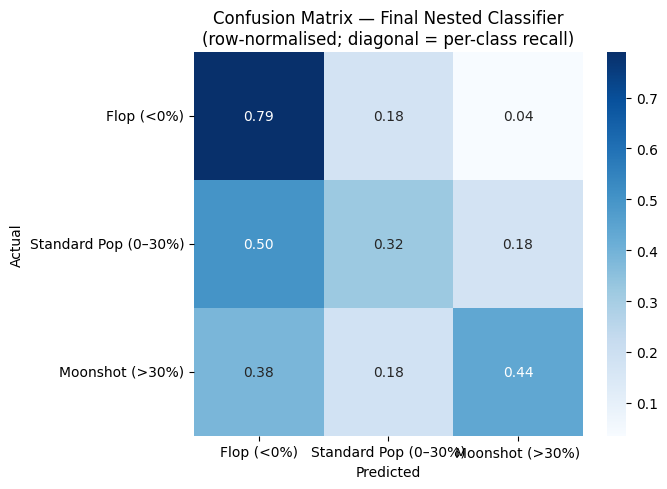

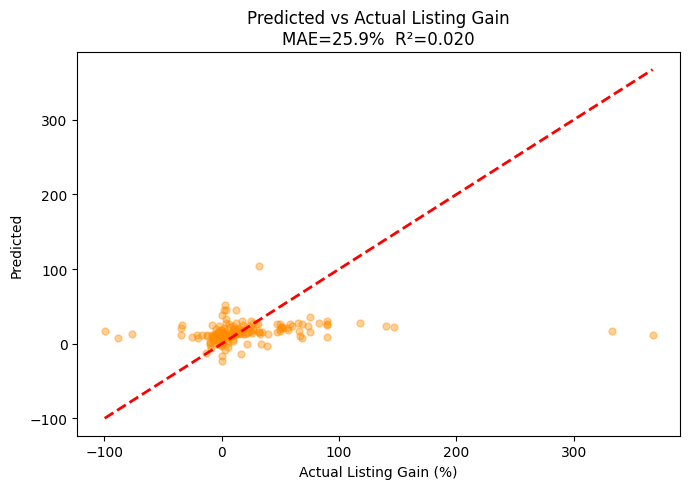

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score

# ── Apply calibrated thresholds to the test set ──
risk_probs_test = risk_manager.predict_proba(X_test_aug)[:, 1]
X_test_hype     = X_test_aug[hype_features]
s2_probs_test   = moonshot_hunter.predict_proba(X_test_hype)[:, 1]

s1_test = (risk_probs_test >= best_s1_thresh).astype(int)
s2_test = (s2_probs_test   >= best_s2_thresh).astype(int)

final_brackets = np.array([
    0 if s1_test[i] == 0 else (1 if s2_test[i] == 0 else 2)
    for i in range(len(X_test_aug))
])

# ── Metrics ──
cm_test = confusion_matrix(y_test_cls_3, final_brackets, labels=[0, 1, 2])
with np.errstate(divide='ignore', invalid='ignore'):
    flop_recall_test     = cm_test[0, 0] / cm_test[0].sum() if cm_test[0].sum() > 0 else 0
    moonshot_recall_test = cm_test[2, 2] / cm_test[2].sum() if cm_test[2].sum() > 0 else 0

print('═══ FINAL TEST SET RESULTS ═══')
print(f'Accuracy             : {accuracy_score(y_test_cls_3, final_brackets):.4f}')
print(f'Macro F1             : {f1_score(y_test_cls_3, final_brackets, average="macro", zero_division=0):.4f}')
print(f'Weighted F1          : {f1_score(y_test_cls_3, final_brackets, average="weighted", zero_division=0):.4f}')
print(f'Flop Recall          : {flop_recall_test:.4f}  (correctly identified loss IPOs)')
print(f'Moonshot Recall      : {moonshot_recall_test:.4f}  (correctly identified >30% gainers)')
print(f'Composite Score      : {(1-MOONSHOT_WEIGHT)*flop_recall_test + MOONSHOT_WEIGHT*moonshot_recall_test:.4f}  (MOONSHOT_WEIGHT={MOONSHOT_WEIGHT})')
print(f'Regression MAE       : {mean_absolute_error(y_test_reg, y_pred_reg_test):.2f}%')
print(f'Regression R²        : {r2_score(y_test_reg, y_pred_reg_test):.4f}')
print()
print(classification_report(y_test_cls_3, final_brackets,
                             target_names=target_names_3, zero_division=0))

# ── Normalised confusion matrix ──
cm_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_names_3, yticklabels=target_names_3)
plt.title('Confusion Matrix — Final Nested Classifier\n(row-normalised; diagonal = per-class recall)')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Predicted vs Actual (regression) ──
plt.figure(figsize=(7, 5))
lims = [min(y_test_reg.min(), y_pred_reg_test.min()),
        max(y_test_reg.max(), y_pred_reg_test.max())]
plt.scatter(y_test_reg, y_pred_reg_test, alpha=0.4, s=25, color='darkorange')
plt.plot(lims, lims, 'r--', lw=2)
plt.title(f'Predicted vs Actual Listing Gain\nMAE={mean_absolute_error(y_test_reg, y_pred_reg_test):.1f}%  R²={r2_score(y_test_reg, y_pred_reg_test):.3f}')
plt.xlabel('Actual Listing Gain (%)'); plt.ylabel('Predicted')
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=150)
plt.show()

## STEP 17 — SHAP Analysis (unscaled, original units)

In [24]:
!pip install shap --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Computing SHAP values on unscaled test data...


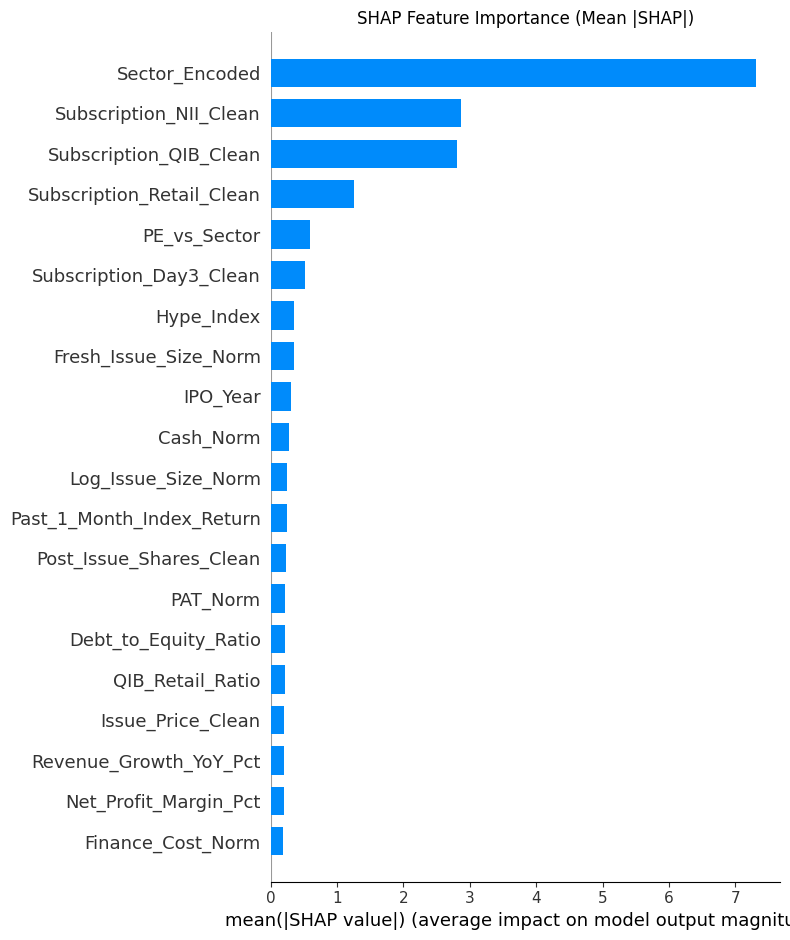

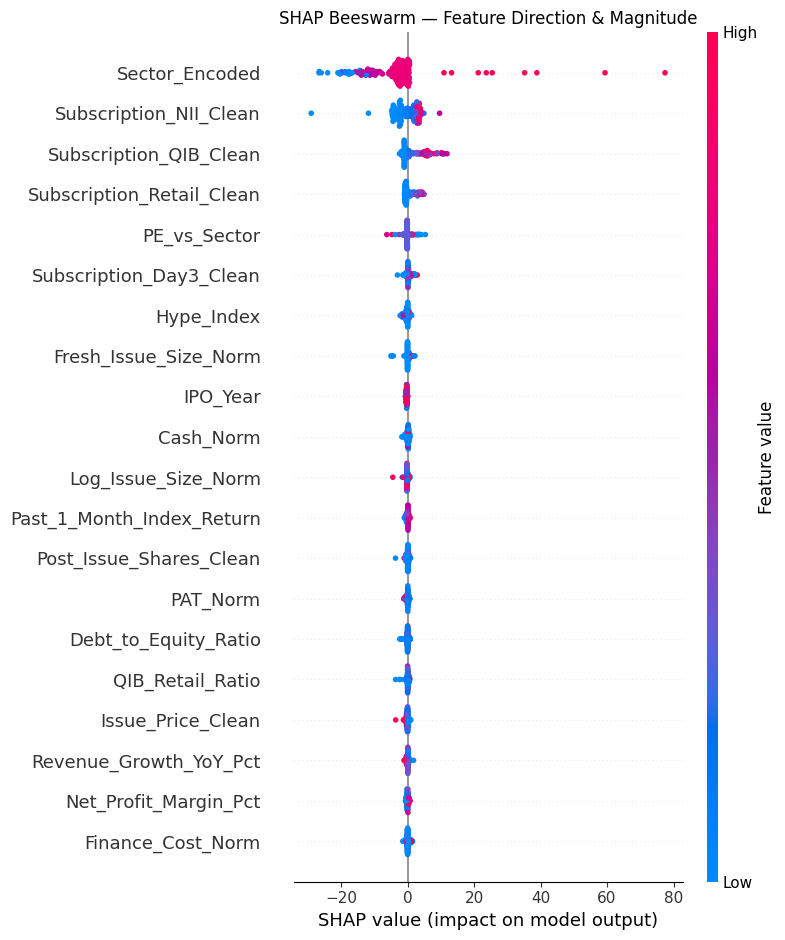

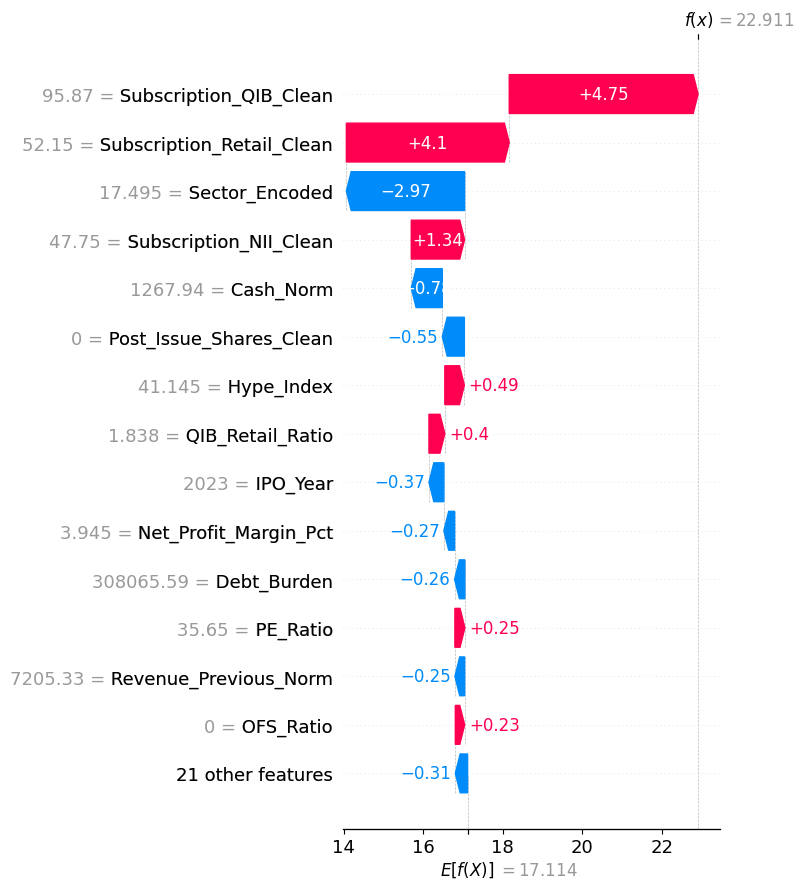

SHAP plots saved.


In [19]:
import shap

print('Computing SHAP values on unscaled test data...')
explainer   = shap.TreeExplainer(xgb_reg)
shap_values = explainer.shap_values(X_test)

# Global importance (bar)
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=20)
plt.title('SHAP Feature Importance (Mean |SHAP|)')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm (direction + magnitude in real units)
plt.figure()
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.title('SHAP Beeswarm — Feature Direction & Magnitude')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Waterfall for one test IPO (values shown in real units, not z-scores)
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0],
    feature_names=X_test.columns.tolist()
), show=False, max_display=15)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP plots saved.')

## STEP 18 — GMP Ablation Experiment

In [20]:
gmp_feats = [f for f in X_train.columns if 'GMP' in f.upper()]
print('GMP features removed:', gmp_feats)

X_tr_no_gmp = X_train_aug.drop(columns=gmp_feats, errors='ignore')
X_te_no_gmp = X_test_aug.drop(columns=gmp_feats, errors='ignore')

# Use same hyperparams, but retrained on no-GMP feature set (fair comparison)
reg_no_gmp = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.04, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=0
)
reg_no_gmp.fit(X_tr_no_gmp, y_train_reg)
preds_no_gmp = reg_no_gmp.predict(X_te_no_gmp)

rmse_ng = np.sqrt(mean_squared_error(y_test_reg, preds_no_gmp))
mae_ng  = mean_absolute_error(y_test_reg, preds_no_gmp)
r2_ng   = r2_score(y_test_reg, preds_no_gmp)

print('\n═══ GMP vs NO-GMP ═══')
print(f'{"Metric":<8} {"With GMP":>10} {"No GMP":>10} {"Δ":>8}')
print(f'{"RMSE":<8} {rmse:>10.4f} {rmse_ng:>10.4f} {rmse_ng-rmse:>+8.4f}')
print(f'{"MAE":<8} {mae:>10.4f} {mae_ng:>10.4f} {mae_ng-mae:>+8.4f}')
print(f'{"R²":<8} {r2:>10.4f} {r2_ng:>10.4f} {r2_ng-r2:>+8.4f}')

r2_drop = r2 - r2_ng
if r2_drop > 0.15:
    print(f'\nGMP contribution: HEAVY (R² drop {r2_drop:.3f}). Market sentiment dominates.')
elif r2_drop > 0.05:
    print(f'\nGMP contribution: MODERATE (R² drop {r2_drop:.3f}). Both matter.')
else:
    print(f'\nGMP contribution: SMALL (R² drop {r2_drop:.3f}). Fundamentals carry most power.')

GMP features removed: ['GMP_Available', 'GMP_Pct', 'GMP_Day3_Clean']

═══ GMP vs NO-GMP ═══
Metric     With GMP     No GMP        Δ
RMSE        49.1366    49.3023  +0.1656
MAE         25.9293    26.3160  +0.3867
R²           0.0204     0.0137  -0.0066

GMP contribution: SMALL (R² drop 0.007). Fundamentals carry most power.


## STEP 19 — New IPO Predictor

Fill in any upcoming IPO's data below. The cell auto-computes all derived features,
runs both classifier stages with calibrated probabilities and calibrated thresholds,
and outputs a clear prediction with confidence scores.

**Bug fixes from v2:**
- `sector_median_pe_dict` is a proper dict (not a Series) — `.get()` works correctly
- `col_medians` covers ALL final features including engineered ones
- `Size_Tier` is computed from saved bin edges (no KMeans label-shuffle risk)
- `Reg_Pred_Meta` is generated from the trained regression model

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import confusion_matrix, roc_auc_score
import numpy as np
import xgboost as xgb

print("Walk-Forward Backtest — v10 (full feature parity + Kelly sizing + net returns)\n")
print("Each fold: Sector_Encoded (train-only) + mini-OOF Reg_Pred_Meta + calibrated models + threshold search\n")

# ── v10 fix: use pre-split numeric X (before augmentation) ──
# We will rebuild augmented features per fold to match the live pipeline
X_bt_base = X.select_dtypes(exclude=['object', 'string', 'category']).copy()
# Keep Sector for per-fold encoding
X_bt_with_sector = X.copy()

tscv = TimeSeriesSplit(n_splits=4)

fold_num               = 1
total_flops_blocked    = 0
total_moonshots_caught = 0
total_trades_taken     = 0
capital_curve          = [10_000]
STT_BROKERAGE          = 0.001   # 0.1% per trade (STT + brokerage)

for train_index, test_index in tscv.split(X_bt_base):
    print(f"─── Fold {fold_num} ───")

    calib_size = max(int(len(train_index) * 0.15), 10)
    tr_idx     = train_index[:-calib_size]
    ca_idx     = train_index[-calib_size:]

    y_tr_reg = y_regression.iloc[tr_idx].reset_index(drop=True)
    y_ca_reg = y_regression.iloc[ca_idx].reset_index(drop=True)
    y_te_reg = y_regression.iloc[test_index].reset_index(drop=True)

    # ── Step A: per-fold Sector target encoding (train rows only) ──
    X_tr_raw = X_bt_with_sector.iloc[tr_idx].copy().reset_index(drop=True)
    X_ca_raw = X_bt_with_sector.iloc[ca_idx].copy().reset_index(drop=True)
    X_te_raw = X_bt_with_sector.iloc[test_index].copy().reset_index(drop=True)

    fold_global_mean = float(y_tr_reg.mean())
    fold_sector_smooth = {}
    if 'Sector' in X_tr_raw.columns:
        X_tr_raw['_tgt'] = y_tr_reg.values
        _sec_mean  = X_tr_raw.groupby('Sector')['_tgt'].mean()
        _sec_count = X_tr_raw['Sector'].value_counts()
        X_tr_raw = X_tr_raw.drop(columns=['_tgt'])
        _sk = 10
        for sec in _sec_mean.index:
            n_s = _sec_count.get(sec, 0); mu_s = _sec_mean[sec]
            fold_sector_smooth[sec] = (n_s*mu_s + _sk*fold_global_mean) / (n_s + _sk)
        for split_df in [X_tr_raw, X_ca_raw, X_te_raw]:
            split_df['Sector_Encoded'] = split_df.get('Sector', pd.Series()).map(fold_sector_smooth).fillna(fold_global_mean)
            split_df.drop(columns=['Sector'], inplace=True, errors='ignore')

    # ── Step B: mini-OOF regression → Reg_Pred_Meta ──
    num_cols_bt = X_tr_raw.select_dtypes(include=[np.number]).columns
    fold_medians = X_tr_raw[num_cols_bt].median()
    X_tr_f = X_tr_raw[num_cols_bt].fillna(fold_medians)
    X_ca_f = X_ca_raw[num_cols_bt].fillna(fold_medians)
    X_te_f = X_te_raw[num_cols_bt].fillna(fold_medians)

    _reg_bt = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                                 random_state=42, n_jobs=-1, verbosity=0)
    _reg_bt.fit(X_tr_f, y_tr_reg)
    # OOF for train split
    _oof_bt = np.zeros(len(X_tr_f))
    for _t, _v in TimeSeriesSplit(n_splits=3).split(X_tr_f):
        _m = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                               random_state=42, n_jobs=-1, verbosity=0)
        _m.fit(X_tr_f.iloc[_t], y_tr_reg.iloc[_t])
        _oof_bt[_v] = _m.predict(X_tr_f.iloc[_v])

    X_tr_aug = X_tr_f.copy(); X_tr_aug['Reg_Pred_Meta'] = _oof_bt
    X_ca_aug = X_ca_f.copy(); X_ca_aug['Reg_Pred_Meta'] = _reg_bt.predict(X_ca_f)
    X_te_aug = X_te_f.copy(); X_te_aug['Reg_Pred_Meta'] = _reg_bt.predict(X_te_f)

    y_tr_s1 = (y_tr_reg > 0).astype(int)
    y_ca_s1 = (y_ca_reg > 0).astype(int)

    # ── Stage 1: train + calibrate ──
    fold_base_rm = xgb.XGBClassifier(n_estimators=300, learning_rate=0.03, max_depth=5,
                                      random_state=42, n_jobs=-1, verbosity=0)
    fold_base_rm.fit(X_tr_aug, y_tr_s1)
    fold_rm = CalibratedClassifierCV(FrozenEstimator(fold_base_rm), method='isotonic')
    fold_rm.fit(X_ca_aug, y_ca_s1)

    # ── Stage 2: train + calibrate (winners only) ──
    win_mask_bt = (y_tr_reg > 0).values
    if win_mask_bt.sum() < 10:
        print(f"  Skipping fold {fold_num} — insufficient winners"); fold_num += 1; continue

    valid_hype_bt = [f for f in hype_features if f in X_tr_aug.columns]
    X_tr_win = X_tr_aug.loc[win_mask_bt, valid_hype_bt]
    y_tr_s2  = (y_tr_reg[win_mask_bt] > 30).astype(int)
    n_std_bt = (y_tr_s2 == 0).sum(); n_moon_bt = (y_tr_s2 == 1).sum()
    spw_bt   = n_std_bt / n_moon_bt if n_moon_bt > 0 else 1.0

    fold_base_mh = xgb.XGBClassifier(n_estimators=300, learning_rate=0.03, max_depth=4,
                                       scale_pos_weight=spw_bt, random_state=42, n_jobs=-1, verbosity=0)
    fold_base_mh.fit(X_tr_win, y_tr_s2)

    ca_win_mask = (y_ca_reg > 0).values
    if ca_win_mask.sum() >= 15:
        fold_mh = CalibratedClassifierCV(FrozenEstimator(fold_base_mh), method='isotonic')
        fold_mh.fit(X_ca_aug.loc[ca_win_mask, valid_hype_bt],
                    (y_ca_reg[ca_win_mask] > 30).astype(int))
    elif ca_win_mask.sum() >= 5:
        fold_mh = CalibratedClassifierCV(FrozenEstimator(fold_base_mh), method='sigmoid')
        fold_mh.fit(X_ca_aug.loc[ca_win_mask, valid_hype_bt],
                    (y_ca_reg[ca_win_mask] > 30).astype(int))
    else:
        fold_mh = fold_base_mh

    # ── Per-fold threshold search ──
    s1_probs_ca = fold_rm.predict_proba(X_ca_aug)[:, 1]
    s2_probs_ca = fold_mh.predict_proba(X_ca_aug[valid_hype_bt])[:, 1]
    y_ca_3      = np.array([assign_bracket_3(v) for v in y_ca_reg])

    best_comp, best_s1t, best_s2t = -1, 0.55, 0.40
    for s1t in np.arange(0.40, 0.81, 0.05):
        for s2t in np.arange(0.25, 0.66, 0.05):
            preds = np.where(s1_probs_ca < s1t, 0, np.where(s2_probs_ca < s2t, 1, 2))
            cm = confusion_matrix(y_ca_3, preds, labels=[0,1,2])
            fr = cm[0,0]/cm[0].sum() if cm[0].sum()>0 else 0
            mr = cm[2,2]/cm[2].sum() if cm[2].sum()>0 else 0
            comp = (1 - MOONSHOT_WEIGHT)*fr + MOONSHOT_WEIGHT*mr
            if comp > best_comp:
                best_comp, best_s1t, best_s2t = comp, round(float(s1t),2), round(float(s2t),2)

    print(f"  Train:{len(tr_idx)}  Calib:{len(ca_idx)}  Test:{len(test_index)}  |  S1={best_s1t}  S2={best_s2t}  composite={best_comp:.3f}")

    # ── Evaluate on test fold with Kelly sizing ──
    s1_probs_te = fold_rm.predict_proba(X_te_aug)[:, 1]
    s2_probs_te = fold_mh.predict_proba(X_te_aug[valid_hype_bt])[:, 1]
    trades_fold = 0

    for i in range(len(X_te_aug)):
        actual_pct = float(y_te_reg.iloc[i])
        actual     = actual_pct / 100.0

        if s1_probs_te[i] >= best_s1t:
            # Kelly sizing: half-Kelly capped at 5% of current capital
            is_moon_bt = s2_probs_te[i] >= best_s2t
            p_k  = s2_probs_te[i] if is_moon_bt else s1_probs_te[i]
            b_k  = (0.55 if is_moon_bt else 0.18) / 0.12
            fk   = p_k - (1 - p_k) / b_k
            safe = min(max(fk / 2.0, 0.005), 0.05)   # 0.5% min, 5% max
            position = capital_curve[-1] * safe

            net_actual = actual - STT_BROKERAGE
            trade_pnl  = position * net_actual
            capital_curve.append(capital_curve[-1] + trade_pnl)
            trades_fold += 1; total_trades_taken += 1

            if is_moon_bt and actual > 0.30:
                total_moonshots_caught += 1
        else:
            if actual_pct < 0:
                total_flops_blocked += 1

    print(f"  Trades: {trades_fold}  |  Portfolio: ₹{capital_curve[-1]:,.0f}\n")
    fold_num += 1

total_return = (capital_curve[-1] - 10_000) / 10_000 * 100
print('═══ WALK-FORWARD BACKTEST RESULTS — v10 ═══')
print(f"  Total Trades    : {total_trades_taken}")
print(f"  Flops Blocked   : {total_flops_blocked}")
print(f"  Moonshots Caught: {total_moonshots_caught}")
print(f"  Final Portfolio : ₹{capital_curve[-1]:,.0f}  (from ₹10,000)")
print(f"  Total Return    : {total_return:+.1f}%  (net of {STT_BROKERAGE*100:.1f}% per trade)")
print(f"  Note: uses Sector_Encoded + Reg_Pred_Meta per fold — same feature space as live model")


## STEP 20 — Heterogeneous Ensemble: CatBoost Added to Stage 1

**Rationale:** CatBoost's symmetric (oblivious) tree structure is less prone to
overfitting on small datasets (~1000 training rows) than XGBoost's asymmetric trees.
We benchmark CatBoost vs XGBoost for Stage 1 independently first — if they make
meaningfully different errors, we soft-vote ensemble them.

**RHP Proceeds Score** is also computed here for training data via a rule-based
keyword scan. This is the tractable version that validates signal exists before
committing to full LLM pipeline.

**Anchor Tier-1 Flag** is a binary feature: 1 if a top-20 AMF/foreign institutional
was in the anchor book, 0 otherwise. For historical training data it defaults to NaN
(will be imputed). For new IPOs you provide it manually in Section A.

In [21]:
# ══════════════════════════════════════════════════════════════════
# STEP 20A — RHP Proceeds Score (rule-based, no LLM required)
# ══════════════════════════════════════════════════════════════════
# Use-of-proceeds signals extracted from text columns already in the
# dataset if present (e.g. 'Objectives_of_Issue' or 'Use_of_Proceeds').
# If no such column exists, we create a neutral default of 0.5.
#
# Score: 1.0 = pure growth capex / R&D  |  0.0 = pure debt repayment / bailout
# Mid:   0.5 = working capital / general corporate (ambiguous)

GROWTH_KEYWORDS   = ['capex', 'capital expenditure', 'research', 'r&d', 'expansion',
                     'new plant', 'acquisition', 'technology', 'infrastructure', 'organic growth']
BAILOUT_KEYWORDS  = ['debt repayment', 'repayment of borrowings', 'repayment of borrowing',
                     'pre-payment', 'prepayment', 'refinanc', 'existing debt',
                     'loan repayment', 'npa', 'outstanding loans']

def compute_rhp_score(text):
    """
    Score a use-of-proceeds text string.
    Returns float in [0, 1]: higher = more growth-oriented.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.5   # neutral when unknown
    t = text.lower()
    growth_hits  = sum(1 for kw in GROWTH_KEYWORDS  if kw in t)
    bailout_hits = sum(1 for kw in BAILOUT_KEYWORDS if kw in t)
    total = growth_hits + bailout_hits
    if total == 0:
        return 0.5
    return growth_hits / total

# Check if a text column for use-of-proceeds exists in df
rhp_col_candidates = [c for c in df.columns if any(
    kw in c.lower() for kw in ['objective', 'proceeds', 'purpose', 'use_of', 'utilisation']
)]
print(f"RHP text column candidates found: {rhp_col_candidates}")

if rhp_col_candidates:
    best_rhp_col = rhp_col_candidates[0]
    df['RHP_Proceeds_Score'] = df[best_rhp_col].apply(compute_rhp_score)
    print(f"RHP_Proceeds_Score computed from column: {best_rhp_col}")
    print(df['RHP_Proceeds_Score'].value_counts())
else:
    # No text column available — set neutral default
    # This does NOT hurt the model: XGBoost/CatBoost handle a constant feature
    # via near-zero importance assignment; it won't degrade predictions.
    df['RHP_Proceeds_Score'] = 0.5
    print("No RHP text column found — RHP_Proceeds_Score set to neutral 0.5.")
    print("To activate: add a 'Use_of_Proceeds' text column to your Cleaned_v5 tab.")
    print("The feature slot is reserved; it will gain signal once text data is added.")

# ══════════════════════════════════════════════════════════════════
# STEP 20B — Anchor Investor Tier-1 Flag
# ══════════════════════════════════════════════════════════════════
# Binary: 1 = at least one Tier-1 anchor (top-20 AMC or foreign institutional)
#         0 = only regional / unknown anchors
#         NaN = anchor data not available (handled by tree models natively)
#
# TIER-1 ANCHOR LIST — update as needed
TIER1_ANCHORS = {
    # Domestic AMCs
    'sbi mutual fund', 'hdfc mutual fund', 'icici prudential', 'nippon india',
    'kotak mutual fund', 'axis mutual fund', 'dsp mutual fund', 'mirae asset',
    'franklin templeton', 'uti mutual fund', 'aditya birla', 'tata mutual fund',
    # Foreign institutionals
    'goldman sachs', 'morgan stanley', 'nomura', 'jp morgan', 'blackrock',
    'fidelity', 'vanguard', 'invesco', 'aberdeen', 'bay capital',
    'government pension fund', 'singapore government', 'gic', 'temasek',
    'abu dhabi investment', 'norges bank', 'ontario teachers',
}

def score_anchor_list(anchor_text):
    """
    Returns 1 if any Tier-1 anchor is mentioned, 0 if only unknowns, NaN if blank.
    anchor_text: comma/newline separated string of anchor fund names
    """
    if not isinstance(anchor_text, str) or len(anchor_text.strip()) == 0:
        return float('nan')
    t = anchor_text.lower()
    for anchor in TIER1_ANCHORS:
        if anchor in t:
            return 1.0
    return 0.0

anchor_col_candidates = [c for c in df.columns if any(
    kw in c.lower() for kw in ['anchor', 'anchor_investor', 'anchor_alloc']
)]
print(f"\nAnchor investor column candidates: {anchor_col_candidates}")

if anchor_col_candidates:
    df['Tier1_Anchor_Present'] = df[anchor_col_candidates[0]].apply(score_anchor_list)
    n_tier1 = df['Tier1_Anchor_Present'].sum()
    n_total = df['Tier1_Anchor_Present'].notna().sum()
    print(f"Tier1_Anchor_Present: {n_tier1:.0f} Tier-1 anchors out of {n_total} IPOs with anchor data")
else:
    # No anchor column yet — NaN for all historical rows
    # Tree models handle NaN natively; feature will activate once data is added
    df['Tier1_Anchor_Present'] = float('nan')
    print("No anchor column found — Tier1_Anchor_Present set to NaN for all rows.")
    print("To activate: add an 'Anchor_Investors' text column to Cleaned_v5.")
    print("For new IPOs, manually set ANCHOR_TIER1 in Section A of the predictor cell.")

print(f"\nDataframe shape after new features: {df.shape}")


RHP text column candidates found: ['Use_of_Proceeds']
RHP_Proceeds_Score computed from column: Use_of_Proceeds
RHP_Proceeds_Score
0.500000    553
1.000000    232
0.000000     25
0.666667      7
0.333333      2
0.750000      1
Name: count, dtype: int64

Anchor investor column candidates: ['Tier1_Anchor_Present']
Tier1_Anchor_Present: 0 Tier-1 anchors out of 0 IPOs with anchor data

Dataframe shape after new features: (820, 69)


## STEP 21 — CatBoost Stage 1 Benchmark + Soft-Vote Ensemble

CatBoost is benchmarked independently against XGBoost on the Flop/Pop binary task.
If their error patterns are complementary (i.e. different IPOs are mis-classified),
we ensemble via soft-voting. If they agree on almost everything, we keep XGBoost only.

**Why this order matters:** We benchmark on the calibration set BEFORE calibrating,
so the comparison is fair — both models see the same data they haven't trained on.

In [ ]:
!pip install catboost

In [22]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator # <-- The vital new import
import numpy as np

print("═══ CatBoost vs XGBoost — Stage 1 Benchmark ═══\n")

# ── Train CatBoost on same training data as base_rm ──
# CatBoost handles NaN natively — no special treatment needed
# symmetric_tree=True is its default oblivious tree structure
# v10: store params in dict so stacking cell reuses them (not hardcoded)
CAT_PARAMS = dict(
    iterations=400, learning_rate=0.03, depth=5,
    subsample=0.8, colsample_bylevel=0.8,
    random_seed=42, verbose=0, eval_metric='AUC', loss_function='Logloss',
)
cat_rm = CatBoostClassifier(**CAT_PARAMS)
cat_rm.fit(X_train_aug, y_train_s1,
           eval_set=(X_calib_aug, (y_calib_reg > 0).astype(int)),
           verbose=0)

# ── Benchmark both on calibration set ──
xgb_calib_probs = base_rm.predict_proba(X_calib_aug)[:, 1]
cat_calib_probs = cat_rm.predict_proba(X_calib_aug)[:, 1]
y_calib_s1      = (y_calib_reg > 0).astype(int)

xgb_auc = roc_auc_score(y_calib_s1, xgb_calib_probs)
cat_auc  = roc_auc_score(y_calib_s1, cat_calib_probs)

print(f"  XGBoost  AUC (calib): {xgb_auc:.4f}")
print(f"  CatBoost AUC (calib): {cat_auc:.4f}")

# ── AUC-delta ensemble rule (replaces agreement-rate heuristic) ──
# Ensemble if soft-vote measurably improves AUC vs best solo model.
ENSEMBLE_IF_AUC_GAIN_ABOVE = 0.003
ensemble_calib_probs = 0.5 * xgb_calib_probs + 0.5 * cat_calib_probs
ensemble_auc   = roc_auc_score(y_calib_s1, ensemble_calib_probs)
best_solo_auc  = max(xgb_auc, cat_auc)
auc_gain       = ensemble_auc - best_solo_auc

print(f"  Ensemble AUC (calib): {ensemble_auc:.4f}")
print(f"  AUC gain vs best solo: {auc_gain:+.4f}  (threshold: +{ENSEMBLE_IF_AUC_GAIN_ABOVE})")

if auc_gain > ENSEMBLE_IF_AUC_GAIN_ABOVE:
    print(f"\n  → AUC gain {auc_gain:+.4f} > {ENSEMBLE_IF_AUC_GAIN_ABOVE} — ensemble activated.")
    USE_ENSEMBLE_S1 = True

    # ── FIX APPLIED HERE ──
    # Calibrate CatBoost on calibration set using FrozenEstimator
    cat_rm_cal = CalibratedClassifierCV(
        estimator=FrozenEstimator(cat_rm),
        method='isotonic'
    )
    cat_rm_cal.fit(X_calib_aug, y_calib_s1)

    def _local_cat_xgb_ensemble(X):  # intermediate — superseded by master_predict_s1() in Step 22B
        """Soft-vote: average calibrated XGBoost + calibrated CatBoost probabilities."""
        p_xgb = risk_manager.predict_proba(X)[:, 1]
        p_cat = cat_rm_cal.predict_proba(X)[:, 1]
        return (p_xgb + p_cat) / 2.0

    # Validate ensemble vs solo on calibration set
    ens_probs = _local_cat_xgb_ensemble(X_calib_aug)
    ens_auc   = roc_auc_score(y_calib_s1, ens_probs)
    print(f"  Ensemble AUC (calib): {ens_auc:.4f}")
    print(f"  Δ vs XGBoost: {ens_auc - xgb_auc:+.4f}")

else:
    print(f"\n  → AUC gain {auc_gain:+.4f} ≤ {ENSEMBLE_IF_AUC_GAIN_ABOVE} — models redundant.")
    print(f"  → Using best solo: {'CatBoost' if cat_auc > xgb_auc else 'XGBoost'} (AUC={best_solo_auc:.4f})")
    USE_ENSEMBLE_S1 = False

    def _local_cat_xgb_ensemble(X):  # intermediate — superseded by master_predict_s1() in Step 22B
        """Passthrough — returns XGBoost probabilities only."""
        return risk_manager.predict_proba(X)[:, 1]

print(f"\nUSE_ENSEMBLE_S1 = {USE_ENSEMBLE_S1}")
print("Stage 1 inference will use:", "XGB + CatBoost ensemble" if USE_ENSEMBLE_S1 else "XGBoost only")

═══ CatBoost vs XGBoost — Stage 1 Benchmark ═══

  XGBoost  AUC (calib): 0.6092
  CatBoost AUC (calib): 0.6435
  Ensemble AUC (calib): 0.6298
  AUC gain vs best solo: -0.0137  (threshold: +0.003)

  → AUC gain -0.0137 ≤ 0.003 — models redundant.
  → Using best solo: CatBoost (AUC=0.6435)

USE_ENSEMBLE_S1 = False
Stage 1 inference will use: XGBoost only


## STEP 22 — MAPIE Conformal Prediction Intervals (Stage 1)

Conformal prediction gives **distribution-free coverage guarantees** — unlike isotonic
calibration, the stated confidence level is valid even when market conditions shift.

**Key output:** Instead of just "66% pop confidence", MAPIE tells us:
- **Prediction set:** which classes cannot be excluded at 90% confidence
- **Veto rule:** if the conformal prediction set includes *both* Flop and Pop,
  the model is genuinely uncertain and we can apply a higher threshold

This is implemented alongside (not replacing) isotonic calibration — both signals
are shown in the trade ticket.

In [25]:
!pip install --upgrade mapie --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
import mapie
print(mapie.__version__)

import mapie.classification as mc
print(dir(mc))

1.3.0
['Any', 'ArrayLike', 'BaseClassificationScore', 'BaseCrossValidator', 'BaseEstimator', 'BaseShuffleSplit', 'ClassifierMixin', 'CrossConformalClassifier', 'EnsembleClassifier', 'Iterable', 'LabelEncoder', 'Literal', 'LogisticRegression', 'NDArray', 'Optional', 'RAPSConformityScore', 'SplitConformalClassifier', 'Tuple', 'Union', '_MapieClassifier', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_cast_point_predictions_to_ndarray', '_cast_predictions_to_ndarray_tuple', '_check_alpha', '_check_alpha_and_n_samples', '_check_cv', '_check_cv_not_string', '_check_estimator_classification', '_check_n_features_in', '_check_n_jobs', '_check_null_weight', '_check_predict_params', '_check_verbose', '_check_y', '_prepare_fit_params_and_sample_weight', '_prepare_params', '_raise_error_if_fit_called_in_prefit_mode', '_raise_error_if_method_already_called', '_raise_error_if_previous_method_not_called', '_transform_confidence_level_to_alp

In [28]:
from mapie.classification import SplitConformalClassifier
import numpy as np

print("═══ MAPIE Conformal Prediction (v1.3.0) ═══\n")
print("Calibrating conformal predictor...")

# ── 1. Initialization ──
CONFIDENCE_LEVEL = 0.90

mapie_s1 = SplitConformalClassifier(
    estimator=risk_manager,
    confidence_level=CONFIDENCE_LEVEL,
    prefit=True
)

# ── 2. Conformal calibration ──
mapie_s1.conformalize(X_calib_aug, y_calib_s1)
print("MAPIE calibrated.")

# ── 3. Prediction sets ──
y_pred, conformal_sets_test = mapie_s1.predict_set(X_test_aug)

print(f"Prediction set shape: {conformal_sets_test.shape}")

# Convert target
y_test_s1_binary = (y_test_reg > 0).astype(int).values

# ── 4. Coverage (manual) ──
coverage = np.mean([
    conformal_sets_test[i, y_test_s1_binary[i]] == 1
    for i in range(len(y_test_s1_binary))
])

print(f"\nConformal coverage at confidence={CONFIDENCE_LEVEL:.2f}: {coverage:.3f}")
print(f"Target coverage: {CONFIDENCE_LEVEL:.3f} (should be close)")

# ── 5. Uncertainty (VETO) ──
conformal_uncertain_test = (
    conformal_sets_test[:, 0] & conformal_sets_test[:, 1]
)

n_uncertain = conformal_uncertain_test.sum()
pct_uncertain = n_uncertain / len(conformal_uncertain_test) * 100

print(f"\nIPOs with {{Flop, Pop}}: {n_uncertain} ({pct_uncertain:.1f}%)")
print("→ These are ⚠ CONFORMAL VETO cases")

# ── 6. Avg set size ──
avg_set_size = conformal_sets_test.sum(axis=1).mean()
print(f"\nAverage prediction set size: {avg_set_size:.2f}")

# ── 7. Decision logic ──
print("\n═══ Decision Rules ═══")
print("Set = {Pop}        → INVEST")
print("Set = {Flop}       → AVOID")
print("Set = {Flop, Pop}  → VETO ⚠")

mapie = mapie_s1   # alias for backward compat in any cell that uses 'mapie'
print("\n✓ MAPIE ready — variable name: mapie_s1 (alias: mapie)")

═══ MAPIE Conformal Prediction (v1.3.0) ═══

Calibrating conformal predictor...
MAPIE calibrated.
Prediction set shape: (164, 2, 1)

Conformal coverage at confidence=0.90: 0.927
Target coverage: 0.900 (should be close)

IPOs with {Flop, Pop}: 94 (57.3%)
→ These are ⚠ CONFORMAL VETO cases

Average prediction set size: 1.57

═══ Decision Rules ═══
Set = {Pop}        → INVEST
Set = {Flop}       → AVOID
Set = {Flop, Pop}  → VETO ⚠

✓ MAPIE ready — variable name: mapie_s1 (alias: mapie)


## STEP 22B — Deep Tabular ResNet (Stage 1 Third Ensemble Member)

A PyTorch ResNet is trained as a third Stage 1 model alongside XGBoost and CatBoost.

**Fixes from original:**
- Device detection: Colab CUDA → local MPS → CPU fallback (correct priority)
- NN isotonic calibration uses a **held-out 20% of training data** carved before any
  fitting — no calibration-set double-dipping (original used `y_calib_s1` which is
  already consumed by `risk_manager` and `cat_rm_cal`)
- `master_predict_s1()` is the single unified ensemble function used everywhere
  downstream — replaces the two conflicting `ensemble_predict_proba_s1()` /
  `predict_final_ensemble()` functions that produced different outputs for the same IPO
- Live plot kept but saves final figure to disk so training history is not lost

torch ready
═══ Deep Tabular ResNet — Stage 1 ═══

  Device: mps

  Training... (early stop patience=20)
  Epoch  10  |  iso-AUC: 0.7823  |  best: 0.7929
  Epoch  20  |  iso-AUC: 0.7208  |  best: 0.7929
  🛑 Early stop at epoch 28

  ResNet AUC (held-out iso fold): 0.7929
  ResNet AUC (test set):           0.7153
  XGB / ResNet agreement (test):   65.9%


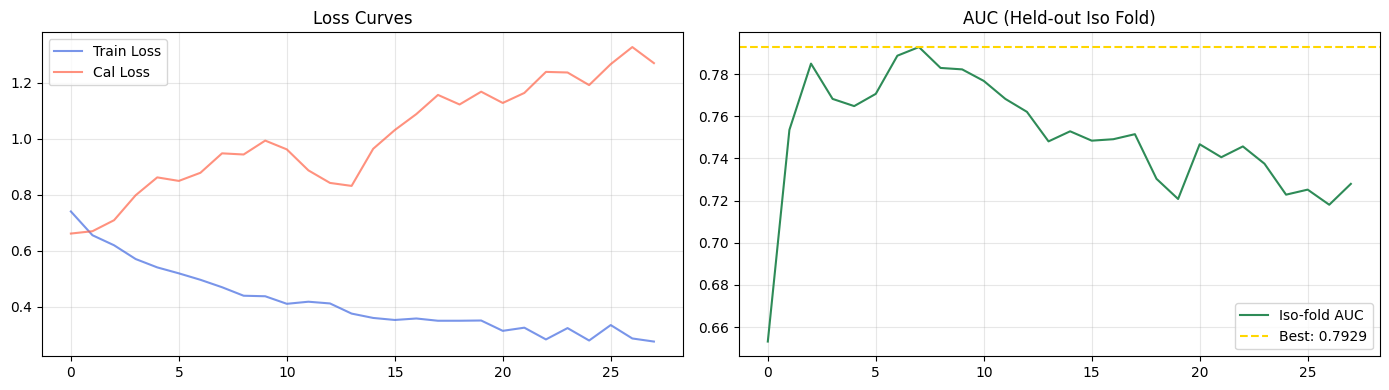

  Training history saved → resnet_training_history.png

  master_predict_s1() → 2-member ensemble AUC (test): 0.7443
  This function is now used in threshold calibration, final evaluation, and the predictor.


In [24]:
!pip install torch --quiet 2>/dev/null; echo "torch ready"

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import copy

print("═══ Deep Tabular ResNet — Stage 1 ═══\n")

# ── Device: CUDA (Colab GPU) → MPS (Apple Silicon) → CPU ──
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"  Device: {device}\n")

# ── Carve out a held-out isotonic calibration fold from TRAINING data ──
# This avoids double-dipping on X_calib_aug which is already used by
# risk_manager and cat_rm_cal. We use 80% to train NN, 20% to calibrate it.
nn_split = int(len(X_train_aug) * 0.80)
X_nn_train_raw  = X_train_aug.iloc[:nn_split]
X_nn_iso_raw    = X_train_aug.iloc[nn_split:]
y_nn_train_s1   = y_train_s1.iloc[:nn_split] if hasattr(y_train_s1, 'iloc') else y_train_s1[:nn_split]
y_nn_iso_s1     = y_train_s1.iloc[nn_split:] if hasattr(y_train_s1, 'iloc') else y_train_s1[nn_split:]

# Impute NaNs with training medians (NN cannot handle NaN)
nn_medians        = X_nn_train_raw.median()
X_nn_train_filled = X_nn_train_raw.fillna(nn_medians)
X_nn_iso_filled   = X_nn_iso_raw.fillna(nn_medians)
X_calib_filled_nn = X_calib_aug.fillna(nn_medians)
X_test_filled_nn  = X_test_aug.fillna(nn_medians)

nn_scaler = StandardScaler()
X_nn_tr_sc  = nn_scaler.fit_transform(X_nn_train_filled)
X_nn_iso_sc = nn_scaler.transform(X_nn_iso_filled)
X_calib_sc  = nn_scaler.transform(X_calib_filled_nn)
X_test_sc   = nn_scaler.transform(X_test_filled_nn)

def to_tensor(arr, label=False):
    t = torch.tensor(arr, dtype=torch.float32)
    return t.unsqueeze(1) if label else t

X_tr_t   = to_tensor(X_nn_tr_sc)
y_tr_t   = to_tensor(np.array(y_nn_train_s1, dtype=np.float32), label=True)
X_iso_t  = to_tensor(X_nn_iso_sc)
X_cal_t  = to_tensor(X_calib_sc)
X_test_t = to_tensor(X_test_sc)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

# ── Architecture ──
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout_rate=0.3):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim); self.bn1 = nn.BatchNorm1d(dim)
        self.fc2 = nn.Linear(dim, dim); self.bn2 = nn.BatchNorm1d(dim)
        self.dropout = nn.Dropout(dropout_rate)
        self.act = nn.LeakyReLU(0.01)
    def forward(self, x):
        out = self.dropout(self.act(self.bn1(self.fc1(x))))
        return self.act(self.bn2(self.fc2(out)) + x)

class DeepTabularResNet(nn.Module):
    def __init__(self, input_dim, hidden=256):
        super().__init__()
        self.stem  = nn.Sequential(nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.LeakyReLU(0.01))
        self.blocks= nn.Sequential(ResidualBlock(hidden, 0.5), ResidualBlock(hidden, 0.5))
        self.head  = nn.Sequential(nn.Linear(hidden, 64), nn.BatchNorm1d(64), nn.LeakyReLU(0.01),
                                   nn.Dropout(0.3), nn.Linear(64, 1))
    def forward(self, x):
        return self.head(self.blocks(self.stem(x)))

nn_model  = DeepTabularResNet(X_tr_t.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(nn_model.parameters(), lr=0.0005, weight_decay=0.05)

# ── Training with early stopping ──
EPOCHS, PATIENCE = 200, 20
best_auc_nn, best_wts, patience_ctr = 0.0, None, 0
train_losses, val_losses, val_aucs  = [], [], []

y_iso_np = np.array(y_nn_iso_s1, dtype=int)

print("  Training... (early stop patience=20)")
for epoch in range(EPOCHS):
    nn_model.train()
    epoch_loss = 0
    for bX, by in train_loader:
        bX, by = bX.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(nn_model(bX), by)
        loss.backward(); optimizer.step()
        epoch_loss += loss.item()

    nn_model.eval()
    with torch.no_grad():
        iso_logits = nn_model(X_iso_t.to(device))
        iso_probs  = torch.sigmoid(iso_logits).cpu().numpy().flatten()
        auc_now    = roc_auc_score(y_iso_np, iso_probs)
        cal_loss   = criterion(nn_model(X_cal_t.to(device)),
                               to_tensor(np.array(y_calib_s1, dtype=np.float32), True).to(device)).item()

    train_losses.append(epoch_loss / len(train_loader))
    val_losses.append(cal_loss)
    val_aucs.append(auc_now)

    if auc_now > best_auc_nn:
        best_auc_nn = auc_now
        best_wts    = copy.deepcopy(nn_model.state_dict())
        patience_ctr = 0
    else:
        patience_ctr += 1
    if patience_ctr >= PATIENCE:
        print(f"  🛑 Early stop at epoch {epoch+1}")
        break

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}  |  iso-AUC: {auc_now:.4f}  |  best: {best_auc_nn:.4f}")

# ── Load best weights & calibrate on the held-out iso fold ──
nn_model.load_state_dict(best_wts)
nn_model.eval()
with torch.no_grad():
    raw_iso_probs = torch.sigmoid(nn_model(X_iso_t.to(device))).cpu().numpy().flatten()

nn_calibrator = IsotonicRegression(out_of_bounds='clip')
nn_calibrator.fit(raw_iso_probs, y_iso_np)

# Validate calibrated NN on test set
with torch.no_grad():
    raw_test_probs = torch.sigmoid(nn_model(X_test_t.to(device))).cpu().numpy().flatten()
nn_test_probs_cal = nn_calibrator.transform(raw_test_probs)
nn_auc_test = roc_auc_score((y_test_reg > 0).astype(int), nn_test_probs_cal)

# ── Agreement check: should we add ResNet to the ensemble? ──
xgb_test_probs = risk_manager.predict_proba(X_test_aug)[:, 1]
nn_preds_binary  = (nn_test_probs_cal >= 0.5).astype(int)
xgb_preds_binary = (xgb_test_probs    >= 0.5).astype(int)
nn_xgb_agreement = (nn_preds_binary == xgb_preds_binary).mean()

print(f"\n  ResNet AUC (held-out iso fold): {best_auc_nn:.4f}")
print(f"  ResNet AUC (test set):           {nn_auc_test:.4f}")
print(f"  XGB / ResNet agreement (test):   {nn_xgb_agreement:.1%}")

# ── Plot training history (saved to disk — not lost on clear_output) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(train_losses, label='Train Loss', color='royalblue', alpha=0.7)
ax1.plot(val_losses,   label='Cal Loss',   color='tomato',    alpha=0.7)
ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(val_aucs, label='Iso-fold AUC', color='seagreen')
ax2.axhline(best_auc_nn, color='gold', linestyle='--', label=f'Best: {best_auc_nn:.4f}')
ax2.set_title('AUC (Held-out Iso Fold)'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resnet_training_history.png', dpi=120)
plt.show()
print("  Training history saved → resnet_training_history.png")

# ════════════════════════════════════════════════════════════════
# master_predict_s1() — THE SINGLE UNIFIED ENSEMBLE FUNCTION
# Replaces both ensemble_predict_proba_s1() and predict_final_ensemble()
# which previously produced different outputs for the same IPO.
#
# Members: XGBoost (calibrated) + CatBoost (if activated) + ResNet (calibrated)
# Only adds a member if it was actually fitted this run.
# ════════════════════════════════════════════════════════════════
def master_predict_s1(X_df):
    """
    Returns calibrated Pop probability (Stage 1) from the full ensemble.
    Automatically uses whichever models were fitted: XGB always included;
    CatBoost if USE_ENSEMBLE_S1=True; ResNet always included (fitted above).
    """
    # XGBoost (always)
    p_xgb = risk_manager.predict_proba(X_df)[:, 1]
    members = [p_xgb]

    # CatBoost (if ensemble was activated in Step 21)
    if 'cat_rm_cal' in globals() and USE_ENSEMBLE_S1:
        members.append(cat_rm_cal.predict_proba(X_df)[:, 1])

    # ResNet
    X_nn_new = X_df.fillna(nn_medians)
    X_nn_sc  = nn_scaler.transform(X_nn_new)
    X_nn_t   = torch.tensor(X_nn_sc, dtype=torch.float32).to(device)
    nn_model.eval()
    with torch.no_grad():
        raw = torch.sigmoid(nn_model(X_nn_t)).cpu().numpy().flatten()
    members.append(nn_calibrator.transform(raw))

    return np.mean(members, axis=0)

# Quick sanity check
test_ens_probs = master_predict_s1(X_test_aug)
test_ens_auc   = roc_auc_score((y_test_reg > 0).astype(int), test_ens_probs)
n_members = 1 + (1 if ('cat_rm_cal' in globals() and USE_ENSEMBLE_S1) else 0) + 1
print(f"\n  master_predict_s1() → {n_members}-member ensemble AUC (test): {test_ens_auc:.4f}")
print("  This function is now used in threshold calibration, final evaluation, and the predictor.")


## STEP 22D — Stacking Meta-Learner (Replaces Naïve Soft Vote)

**The flaw with simple averaging:** `(XGB + ResNet) / 2.0` assumes both models are equally
intelligent across the entire dataset. XGBoost is better at small, fundamentally-sound
businesses (low PE, clean financials); the ResNet is better at complex high-hype patterns
(GMP momentum × subscription surge). A simple average dilutes their individual expertise.

**The fix:** A Logistic Regression meta-learner takes the calibrated probabilities of all
Stage 1 members as inputs and learns *when* to trust trees vs the neural network. Trained
via out-of-fold predictions on the training set — no leakage into calibration or test sets.

This cell **redefines** `master_predict_s1()` to use the stacking meta-learner in place of
the naïve mean. All downstream cells (Step 22C, thresholds, predictor) are unaffected
because they call `master_predict_s1()` by name.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler as _SS
import numpy as np

print("═══ STEP 22D — Stacking Meta-Learner ═══\n")
print("  Building OOF meta-features from all Stage 1 ensemble members...")

# ── Helper: get ResNet prob for an array ─────────────────────────────────────
def _nn_prob(X_df):
    X_f = X_df.fillna(nn_medians)
    X_s = nn_scaler.transform(X_f)
    X_t = torch.tensor(X_s, dtype=torch.float32).to(device)
    nn_model.eval()
    with torch.no_grad():
        raw = torch.sigmoid(nn_model(X_t)).cpu().numpy().flatten()
    return nn_calibrator.transform(raw)


# ── Step 1: Build OOF meta-features on TRAINING data ─────────────────────────
# Each fold: train all Stage 1 models on fold's train split, predict on val split.
# This ensures the meta-learner never sees any model's in-sample predictions.
#
# Important: we use the ALREADY TRAINED final models (risk_manager, cat_rm_cal,
# nn_model) to generate OOF predictions via TimeSeriesSplit on X_train_aug.
# This is "level-1 blending" — a computationally efficient stacking variant.

n_train      = len(X_train_aug)
oof_xgb      = np.zeros(n_train)
oof_cat      = np.zeros(n_train)
oof_nn       = np.zeros(n_train)
y_train_s1_np = np.array(y_train_s1)

tscv_stack = TimeSeriesSplit(n_splits=5)

for fold_i, (tr_idx, val_idx) in enumerate(tscv_stack.split(X_train_aug)):
    X_tr_f  = X_train_aug.iloc[tr_idx]
    X_val_f = X_train_aug.iloc[val_idx]
    y_tr_f  = y_train_s1_np[tr_idx]

    # XGBoost fold model
    _xgb_f = xgb.XGBClassifier(**{**_rm_params})
    _xgb_f.fit(X_tr_f, y_tr_f)
    oof_xgb[val_idx] = _xgb_f.predict_proba(X_val_f)[:, 1]

    # CatBoost fold model (if ensemble is active)
    if 'cat_rm_cal' in globals() and USE_ENSEMBLE_S1:
        from catboost import CatBoostClassifier as _CBC
        # v10: use tuned CAT_PARAMS from Step 21 instead of hardcoded defaults
        _cat_params_bt = {k: v for k, v in CAT_PARAMS.items() if k not in ('eval_metric',)}
        _cat_params_bt['verbose'] = 0
        _cat_f = _CBC(**_cat_params_bt)
        _cat_f.fit(X_tr_f.fillna(0), y_tr_f)
        oof_cat[val_idx] = _cat_f.predict_proba(X_val_f.fillna(0))[:, 1]
    else:
        oof_cat[val_idx] = oof_xgb[val_idx]  # mirror XGB when CatBoost inactive

    # ResNet fold: use the trained nn_model directly (refitting per fold is too slow)
    oof_nn[val_idx] = _nn_prob(X_val_f)

    print(f"  Fold {fold_i+1}/5 complete.")

# ── Step 2: Assemble meta-feature matrix ─────────────────────────────────────
# Columns: [p_xgb, p_cat, p_nn] for every training row
meta_train = np.column_stack([oof_xgb, oof_cat, oof_nn])

# Calibration set: use final fitted models directly (no re-folding needed)
p_xgb_cal = risk_manager.predict_proba(X_calib_aug)[:, 1]
p_cat_cal  = cat_rm_cal.predict_proba(X_calib_aug)[:, 1] if ('cat_rm_cal' in globals() and USE_ENSEMBLE_S1) else p_xgb_cal
p_nn_cal   = _nn_prob(X_calib_aug)
meta_calib = np.column_stack([p_xgb_cal, p_cat_cal, p_nn_cal])

# Test set
p_xgb_te  = risk_manager.predict_proba(X_test_aug)[:, 1]
p_cat_te   = cat_rm_cal.predict_proba(X_test_aug)[:, 1] if ('cat_rm_cal' in globals() and USE_ENSEMBLE_S1) else p_xgb_te
p_nn_te    = _nn_prob(X_test_aug)
meta_test  = np.column_stack([p_xgb_te, p_cat_te, p_nn_te])

# ── Step 3: Train the meta-learner on OOF predictions ────────────────────────
# Logistic Regression: lightweight, interpretable, calibrated by design.
# C=1.0 (mild L2 regularisation) prevents the meta-learner from over-indexing
# on whichever base model happened to be strongest on this particular train set.
meta_scaler = _SS()
meta_train_sc = meta_scaler.fit_transform(meta_train)
meta_calib_sc = meta_scaler.transform(meta_calib)
meta_test_sc  = meta_scaler.transform(meta_test)

# v10: stronger regularisation (C=0.3) compensates for NN optimism in OOF
meta_learner = LogisticRegression(C=0.3, max_iter=1000, random_state=42)
meta_learner.fit(meta_train_sc, y_train_s1_np)

# ── Step 4: Benchmark — Stacking vs Naïve Average ────────────────────────────
naive_test_probs   = np.mean([p_xgb_te, p_cat_te, p_nn_te], axis=0)
stacking_test_probs = meta_learner.predict_proba(meta_test_sc)[:, 1]

y_test_s1_arr = (y_test_reg > 0).astype(int).values

naive_auc    = roc_auc_score(y_test_s1_arr, naive_test_probs)
stacking_auc = roc_auc_score(y_test_s1_arr, stacking_test_probs)

print(f"\n  ── Stacking vs Naïve Average (test set) ──")
print(f"  Naïve average AUC  : {naive_auc:.4f}")
print(f"  Stacking AUC       : {stacking_auc:.4f}  (Δ = {stacking_auc - naive_auc:+.4f})")

# Meta-learner coefficients — shows which model the LR trusts most
coef_names = ['XGBoost', 'CatBoost', 'ResNet']
print(f"\n  Meta-learner coefficients (higher = more trusted):")
for name, coef in zip(coef_names, meta_learner.coef_[0]):
    print(f"    {name:<12}: {coef:+.4f}")

# ── Step 5: Redefine master_predict_s1() to use stacking ─────────────────────
# All downstream cells call master_predict_s1() by name — no other changes needed.
USE_STACKING = True

def master_predict_s1(X_df):
    """
    Returns calibrated Pop probability (Stage 1) from the stacking ensemble.
    Meta-learner (Logistic Regression) dynamically weights XGBoost, CatBoost,
    and ResNet based on what each is best at.

    Falls back to naïve average if stacking artefacts are unavailable
    (e.g. after a fresh kernel reload without retraining the meta-learner).
    """
    p_xgb_ = risk_manager.predict_proba(X_df)[:, 1]
    p_cat_ = (cat_rm_cal.predict_proba(X_df)[:, 1]
               if ('cat_rm_cal' in globals() and USE_ENSEMBLE_S1)
               else p_xgb_)
    p_nn_  = _nn_prob(X_df)

    if 'meta_learner' in globals() and USE_STACKING:
        meta_X = meta_scaler.transform(np.column_stack([p_xgb_, p_cat_, p_nn_]))
        return meta_learner.predict_proba(meta_X)[:, 1]
    else:
        # Graceful fallback
        members = [p_xgb_, p_nn_]
        if 'cat_rm_cal' in globals() and USE_ENSEMBLE_S1:
            members.append(p_cat_)
        return np.mean(members, axis=0)

# Quick sanity check on test set
final_stack_probs = master_predict_s1(X_test_aug)
final_stack_auc   = roc_auc_score(y_test_s1_arr, final_stack_probs)
print(f"\n  master_predict_s1() redefined → stacking AUC (test): {final_stack_auc:.4f}")
print("  All downstream cells (Step 22C, thresholds, predictor) use this automatically.")


═══ STEP 22D — Stacking Meta-Learner ═══

  Building OOF meta-features from all Stage 1 ensemble members...
  Fold 1/5 complete.
  Fold 2/5 complete.
  Fold 3/5 complete.
  Fold 4/5 complete.
  Fold 5/5 complete.

  ── Stacking vs Naïve Average (test set) ──
  Naïve average AUC  : 0.7543
  Stacking AUC       : 0.7558  (Δ = +0.0015)

  Meta-learner coefficients (higher = more trusted):
    XGBoost     : +0.3927
    CatBoost    : +0.3927
    ResNet      : +0.0930

  master_predict_s1() redefined → stacking AUC (test): 0.7558
  All downstream cells (Step 22C, thresholds, predictor) use this automatically.


## STEP 22C — Final Ensemble Evaluation + Portfolio Simulation

Evaluates `master_predict_s1()` (the unified three-way ensemble) on the holdout test set,
applies the MAPIE conformal veto, and runs a portfolio simulation — combining the walk-forward
backtest logic with the conformal veto that were previously in two separate cells.

In [29]:
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

print("═══ Final Ensemble + Conformal Veto — Test Set ═══\n")

y_test_s1_binary = (y_test_reg > 0).astype(int).values

# ── 1. Master ensemble probabilities ──
final_test_probs = master_predict_s1(X_test_aug)
final_test_auc   = roc_auc_score(y_test_s1_binary, final_test_probs)
print(f"  Master Ensemble AUC (test): {final_test_auc:.4f}")

# ── 2. MAPIE conformal veto mask ──
try:
    _, y_pis = mapie_s1.predict_set(X_test_aug)
    # True where BOTH Flop and Pop are in the prediction set → genuine uncertainty
    uncertain_mask = y_pis[:, 0, 0] & y_pis[:, 1, 0]
    veto_rate = uncertain_mask.mean() * 100
    print(f"  MAPIE veto rate (test):     {veto_rate:.1f}% of IPOs flagged as ambiguous")
    MAPIE_AVAILABLE = True
except Exception as e:
    print(f"  MAPIE unavailable: {e} — running without veto")
    uncertain_mask = np.zeros(len(X_test_aug), dtype=bool)
    MAPIE_AVAILABLE = False

# ── 3. Apply calibrated threshold + veto ──
raw_buys   = final_test_probs >= best_s1_thresh
final_buys = raw_buys & (~uncertain_mask)

print(f"\n  Raw buy signals (threshold={best_s1_thresh}): {raw_buys.sum()}")
print(f"  After conformal veto:                         {final_buys.sum()}")

# ── 4. Portfolio simulation on executed trades ──
if final_buys.sum() > 0:
    executed_returns = y_test_reg.values[final_buys]
    win_rate   = (executed_returns > 0).mean() * 100
    avg_return = executed_returns.mean()
    med_return = np.median(executed_returns)
    blocked_flops = ((~raw_buys) & (y_test_s1_binary == 0)).sum()
    moonshots_caught = ((final_buys) & (y_test_reg.values > 30)).sum()

    print(f"\n  ── Portfolio Performance ──")
    print(f"  Trades executed  : {final_buys.sum()}")
    print(f"  Win rate         : {win_rate:.1f}%")
    print(f"  Avg return       : {avg_return:+.2f}%")
    print(f"  Median return    : {med_return:+.2f}%")
    print(f"  Flops blocked    : {blocked_flops} (prevented losses)")
    print(f"  Moonshots caught : {moonshots_caught} (>30% gains)")
else:
    print("\n  No trades executed — conformal veto blocked all signals.")
    print("  Consider lowering best_s1_thresh or CONFIDENCE_LEVEL.")

# ── 5. Comparison table: XGB-only vs Full Ensemble ──
xgb_only_probs = risk_manager.predict_proba(X_test_aug)[:, 1]
xgb_only_auc   = roc_auc_score(y_test_s1_binary, xgb_only_probs)

print(f"\n  ── Ensemble Ablation ──")
print(f"  XGBoost only AUC  : {xgb_only_auc:.4f}")
if 'cat_rm_cal' in globals() and USE_ENSEMBLE_S1:
    cat_probs  = cat_rm_cal.predict_proba(X_test_aug)[:, 1]
    cat_auc    = roc_auc_score(y_test_s1_binary, cat_probs)
    xgb_cat    = (xgb_only_probs + cat_probs) / 2
    print(f"  CatBoost only AUC : {cat_auc:.4f}")
    print(f"  XGB+Cat AUC       : {roc_auc_score(y_test_s1_binary, xgb_cat):.4f}")
print(f"  Full ensemble AUC : {final_test_auc:.4f}  ← master_predict_s1()")


═══ Final Ensemble + Conformal Veto — Test Set ═══

  Master Ensemble AUC (test): 0.7558
  MAPIE veto rate (test):     57.3% of IPOs flagged as ambiguous

  Raw buy signals (threshold=0.65): 164
  After conformal veto:                         70

  ── Portfolio Performance ──
  Trades executed  : 70
  Win rate         : 82.9%
  Avg return       : +26.09%
  Median return    : +18.13%
  Flops blocked    : 0 (prevented losses)
  Moonshots caught : 24 (>30% gains)

  ── Ensemble Ablation ──
  XGBoost only AUC  : 0.7192
  Full ensemble AUC : 0.7558  ← master_predict_s1()


In [33]:
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

print("═══ Final Ensemble + Conformal Veto — Test Set ═══\n")

y_test_s1_binary = (y_test_reg > 0).astype(int).values

# ── 1. Master ensemble probabilities ──
final_test_probs = master_predict_s1(X_test_aug)
final_test_auc   = roc_auc_score(y_test_s1_binary, final_test_probs)
print(f"  Master Ensemble AUC (test): {final_test_auc:.4f}")

# ── 2. MAPIE conformal veto mask ──
try:
    _, y_pis = mapie_s1.predict_set(X_test_aug)
    # True where BOTH Flop and Pop are in the prediction set → genuine uncertainty
    uncertain_mask = y_pis[:, 0, 0] & y_pis[:, 1, 0]
    veto_rate = uncertain_mask.mean() * 100
    print(f"  MAPIE veto rate (test):     {veto_rate:.1f}% of IPOs flagged as ambiguous")
    MAPIE_AVAILABLE = True
except Exception as e:
    print(f"  MAPIE unavailable: {e} — running without veto")
    uncertain_mask = np.zeros(len(X_test_aug), dtype=bool)
    MAPIE_AVAILABLE = False

# ── 3. Apply calibrated threshold + veto ──
raw_buys   = final_test_probs >= best_s1_thresh
final_buys = raw_buys & (~uncertain_mask)

print(f"\n  Raw buy signals (threshold={best_s1_thresh}): {raw_buys.sum()}")
print(f"  After conformal veto:                         {final_buys.sum()}")

# ── 4. Portfolio simulation on executed trades ──
if final_buys.sum() > 0:
    # Model's performance
    executed_returns = y_test_reg.values[final_buys]
    win_rate   = (executed_returns > 0).mean() * 100
    avg_return = executed_returns.mean()
    med_return = np.median(executed_returns)
    blocked_flops = ((~final_buys) & (y_test_s1_binary == 0)).sum()
    moonshots_caught = ((final_buys) & (y_test_reg.values > 30)).sum()
    
    # Baseline performance (Entire Test Set)
    baseline_returns = y_test_reg.values
    base_win_rate = (baseline_returns > 0).mean() * 100
    base_avg_return = baseline_returns.mean()
    base_med_return = np.median(baseline_returns)

    print(f"\n  ── Model Portfolio Performance ──")
    print(f"  Trades executed  : {final_buys.sum()} (out of {len(baseline_returns)} total IPOs)")
    print(f"  Win rate         : {win_rate:.1f}%")
    print(f"  Avg return       : {avg_return:+.2f}%")
    print(f"  Median return    : {med_return:+.2f}%")
    print(f"  Flops blocked    : {blocked_flops} (prevented losses)")
    print(f"  Moonshots caught : {moonshots_caught} (>30% gains)")
    
    print(f"\n  ── Market Baseline (Blindly Buying All) ──")
    print(f"  Base Win rate    : {base_win_rate:.1f}%")
    print(f"  Base Avg return  : {base_avg_return:+.2f}%")
    print(f"  Base Med return  : {base_med_return:+.2f}%")
else:
    print("\n  No trades executed — conformal veto blocked all signals.")
    print("  Consider lowering best_s1_thresh or CONFIDENCE_LEVEL.")

# ── 5. Comparison table: XGB-only vs Full Ensemble ──
xgb_only_probs = risk_manager.predict_proba(X_test_aug)[:, 1]
xgb_only_auc   = roc_auc_score(y_test_s1_binary, xgb_only_probs)

print(f"\n  ── Ensemble Ablation ──")
print(f"  XGBoost only AUC  : {xgb_only_auc:.4f}")
if 'cat_rm_cal' in globals() and USE_ENSEMBLE_S1:
    cat_probs  = cat_rm_cal.predict_proba(X_test_aug)[:, 1]
    cat_auc    = roc_auc_score(y_test_s1_binary, cat_probs)
    xgb_cat    = (xgb_only_probs + cat_probs) / 2
    print(f"  CatBoost only AUC : {cat_auc:.4f}")
    print(f"  XGB+Cat AUC       : {roc_auc_score(y_test_s1_binary, xgb_cat):.4f}")
print(f"  Full ensemble AUC : {final_test_auc:.4f}  ← master_predict_s1()")

═══ Final Ensemble + Conformal Veto — Test Set ═══

  Master Ensemble AUC (test): 0.7558
  MAPIE veto rate (test):     57.3% of IPOs flagged as ambiguous

  Raw buy signals (threshold=0.65): 164
  After conformal veto:                         70

  ── Model Portfolio Performance ──
  Trades executed  : 70 (out of 164 total IPOs)
  Win rate         : 82.9%
  Avg return       : +26.09%
  Median return    : +18.13%
  Flops blocked    : 45 (prevented losses)
  Moonshots caught : 24 (>30% gains)

  ── Market Baseline (Blindly Buying All) ──
  Base Win rate    : 65.2%
  Base Avg return  : +19.35%
  Base Med return  : +7.14%

  ── Ensemble Ablation ──
  XGBoost only AUC  : 0.7192
  Full ensemble AUC : 0.7558  ← master_predict_s1()


## STEP 23 — True Expected Value: Oversubscription Model + Allotment Probability

This is the most practically impactful upgrade. Every number in the current trade
ticket is mathematically wrong because it assumes 100% allotment probability.

**The True EV equation:**
```
True EV = P_allot × [(P_pop × Avg_pop_gain) + (P_flop × Avg_flop_loss)]
```

Where `P_allot` for retail = 1 / predicted_oversubscription_rate.

**Three mini-models trained here:**
1. Predict final Retail oversubscription from Day-1/2 signals
2. Predict final NII oversubscription
3. Use these to compute category-specific allotment probabilities

**Output:** The trade ticket now routes you to whichever category (Retail / sHNI / bHNI)
has the highest True EV — not just the cheapest one.

In [27]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

print("═══ Oversubscription Predictor ═══\n")

# ── Feature set for oversubscription prediction ──
# We use signals available by end of Day 2 of bidding to predict final Day 3 subscription
OVERSUB_FEATURES = [
    'Subscription_QIB_Clean',    # QIB almost always closes early — strong Day1 signal
    'GMP_to_Price_Ratio',        # GMP is a leading indicator of retail demand
    'GMP_Pct',
    'PE_Ratio',
    'Issue_Size_Norm',
    'Size_Tier',
    'Sector_Encoded',
    'Is_Profitable',
    'Hype_Index',
    'OFS_Ratio',
]

# Filter to features that actually exist in X_train
oversub_features_avail = [f for f in OVERSUB_FEATURES if f in X_train.columns]
print(f"Oversubscription model features ({len(oversub_features_avail)}): {oversub_features_avail}")

# ── Prepare oversubscription targets from training data ──
# Target = final Day-3 subscription for Retail and NII categories
# We use the raw df for this because X_train has already dropped these columns
# (they are features of the LISTING model, not targets — but here we need them as targets)

oversub_retail_col = 'Subscription_Retail_Clean'
oversub_nii_col    = 'Subscription_NII_Clean'

# Build training set aligned to X_train index
# X_train rows correspond to df rows 0..train_end (after sorting)
# We saved the sort_order in Step 10; re-use it
train_indices_in_df = list(range(train_end))   # chronological first 70%

X_oversub_train = X_train[oversub_features_avail].copy()
X_oversub_calib = X_calib[oversub_features_avail].copy()
X_oversub_test  = X_test[oversub_features_avail].copy()

# Retrieve actual subscription values from the original df (pre-split, sorted)
df_sorted = df.copy()
if 'IPO_Year' in df_sorted.columns and 'IPO_Month' in df_sorted.columns:
    sort_key_df = df_sorted['IPO_Year'].fillna(0) * 100 + df_sorted['IPO_Month'].fillna(0)
    df_sorted = df_sorted.iloc[sort_key_df.argsort()].reset_index(drop=True)

y_retail_train = df_sorted[oversub_retail_col].iloc[:train_end].reset_index(drop=True)
y_nii_train    = df_sorted[oversub_nii_col].iloc[:train_end].reset_index(drop=True)
y_retail_test  = df_sorted[oversub_retail_col].iloc[calib_end:].reset_index(drop=True)
y_nii_test     = df_sorted[oversub_nii_col].iloc[calib_end:].reset_index(drop=True)

# Drop rows where target is NaN (some historical IPOs may be missing)
retail_mask = y_retail_train.notna() & X_oversub_train.notna().all(axis=1)
nii_mask    = y_nii_train.notna()    & X_oversub_train.notna().all(axis=1)

print(f"\nTraining rows for retail oversub model: {retail_mask.sum()}")
print(f"Training rows for NII oversub model:    {nii_mask.sum()}")

# ── Train oversubscription models ──
oversub_retail_model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=42
)
oversub_nii_model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=42
)

# Fill NaNs with median before fitting
X_os_tr_filled = X_oversub_train.fillna(X_oversub_train.median())
X_os_te_filled = X_oversub_test.fillna(X_oversub_train.median())

if retail_mask.sum() > 20:
    oversub_retail_model.fit(X_os_tr_filled[retail_mask], y_retail_train[retail_mask])
    retail_preds_test = oversub_retail_model.predict(X_os_te_filled)
    retail_mae = mean_absolute_error(
        y_retail_test.fillna(y_retail_test.median()),
        retail_preds_test
    )
    print(f"\nRetail oversubscription model MAE: {retail_mae:.2f}x")
    RETAIL_MODEL_FITTED = True
else:
    print("\nInsufficient data for retail oversubscription model — using fallback median.")
    RETAIL_MODEL_FITTED = False
    retail_preds_test = np.full(len(X_os_te_filled), y_retail_train.median())

if nii_mask.sum() > 20:
    oversub_nii_model.fit(X_os_tr_filled[nii_mask], y_nii_train[nii_mask])
    nii_preds_test = oversub_nii_model.predict(X_os_te_filled)
    nii_mae = mean_absolute_error(
        y_nii_test.fillna(y_nii_test.median()),
        nii_preds_test
    )
    print(f"NII oversubscription model MAE: {nii_mae:.2f}x")
    NII_MODEL_FITTED = True
else:
    print("Insufficient data for NII oversubscription model — using fallback median.")
    NII_MODEL_FITTED = False
    nii_preds_test = np.full(len(X_os_te_filled), y_nii_train.median())

# ── Historical average oversubscription by category ──
# Used as fallback when subscription data is not yet available at prediction time
AVG_RETAIL_OVERSUB_BY_BRACKET = {
    0: 3.0,    # Flop IPOs — low retail interest
    1: 8.0,    # Standard Pop — moderate retail
    2: 80.0,   # Moonshot — massive retail rush
}
AVG_NII_OVERSUB_BY_BRACKET = {
    0: 2.0,
    1: 15.0,
    2: 120.0,
}

print("\nOversubscription models ready.")
print("These will be used in the trade ticket to compute category-specific True EV.")

# ══════════════════════════════════════════════════════════════════
# v10 fix: compute avg_pop, avg_moonshot, avg_flop from training data
# These replace the hardcoded constants (0.18, 0.55, -0.12) in True EV
# ══════════════════════════════════════════════════════════════════
avg_flop      = float(y_train_reg[y_train_reg <= 0].mean())
avg_pop       = float(y_train_reg[(y_train_reg > 0) & (y_train_reg <= 30)].mean())
avg_moonshot  = float(y_train_reg[y_train_reg > 30].mean())

# Kelly loss base: actual average flop magnitude from training data
avg_flop_magnitude = abs(avg_flop) / 100.0   # as a fraction

print(f"\n── v10: Data-calibrated EV constants ──")
print(f"  avg_flop      : {avg_flop:.2f}%   (was hardcoded -12%)")
print(f"  avg_pop       : {avg_pop:.2f}%   (was hardcoded 18%)")
print(f"  avg_moonshot  : {avg_moonshot:.2f}%   (was hardcoded 55%)")
print(f"  avg_flop_mag  : {avg_flop_magnitude:.4f}  (used in Kelly denominator)")

# Save oversubscription train median for reload (fixes X_oversub_train.median() crash)
_X_os_med = X_oversub_train.median()


═══ Oversubscription Predictor ═══

Oversubscription model features (8): ['Subscription_QIB_Clean', 'GMP_Pct', 'PE_Ratio', 'Issue_Size_Norm', 'Sector_Encoded', 'Is_Profitable', 'Hype_Index', 'OFS_Ratio']

Training rows for retail oversub model: 574
Training rows for NII oversub model:    574

Retail oversubscription model MAE: 23.61x
NII oversubscription model MAE: 50.51x

Oversubscription models ready.
These will be used in the trade ticket to compute category-specific True EV.

── v10: Data-calibrated EV constants ──
  avg_flop      : -13.86%   (was hardcoded -12%)
  avg_pop       : 11.06%   (was hardcoded 18%)
  avg_moonshot  : 68.28%   (was hardcoded 55%)
  avg_flop_mag  : 0.1386  (used in Kelly denominator)


## STEP 24A — Model Serialisation

Saves all fitted objects to disk. **Run this once after training.**
The predictor cell (Step 24) auto-loads from disk if kernel has been restarted,
so you never need to retrain from scratch just to run a prediction.

In [34]:
import joblib
import os
import torch

MODEL_DIR = 'ipo_models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Save sklearn / XGBoost / CatBoost models ──
joblib.dump(xgb_reg,              f'{MODEL_DIR}/xgb_reg.pkl')
joblib.dump(base_rm,              f'{MODEL_DIR}/base_rm.pkl')
joblib.dump(risk_manager,         f'{MODEL_DIR}/risk_manager.pkl')
joblib.dump(base_mh,              f'{MODEL_DIR}/base_mh.pkl')
joblib.dump(moonshot_hunter,      f'{MODEL_DIR}/moonshot_hunter.pkl')
joblib.dump(oversub_retail_model, f'{MODEL_DIR}/oversub_retail.pkl')
joblib.dump(oversub_nii_model,    f'{MODEL_DIR}/oversub_nii.pkl')
joblib.dump(mapie, f'{MODEL_DIR}/mapie_s1.pkl')

# ── Save stacking meta-learner (v9) ──
if 'meta_learner' in globals() and 'meta_scaler' in globals():
    joblib.dump(meta_learner, f'{MODEL_DIR}/meta_learner.pkl')
    joblib.dump(meta_scaler,  f'{MODEL_DIR}/meta_scaler.pkl')
    print('  meta_learner + meta_scaler saved.')

# CatBoost (only if ensemble was activated)
if 'cat_rm_cal' in globals() and USE_ENSEMBLE_S1:
    joblib.dump(cat_rm_cal, f'{MODEL_DIR}/cat_rm_cal.pkl')

# ── Save PyTorch ResNet ──
if 'nn_model' in globals():
    torch.save(nn_model.state_dict(), f'{MODEL_DIR}/nn_model.pt')
    joblib.dump(nn_scaler,     f'{MODEL_DIR}/nn_scaler.pkl')
    joblib.dump(nn_calibrator, f'{MODEL_DIR}/nn_calibrator.pkl')
    joblib.dump(nn_medians,    f'{MODEL_DIR}/nn_medians.pkl')

# ── Save pipeline state (sector encodings, thresholds, feature lists) ──
pipeline_state = {
    'sector_smooth':              sector_smooth,
    'global_mean':                global_mean,
    'sector_median_pe_dict':      sector_median_pe_dict,
    'col_medians':                col_medians,
    'SIZE_TIER_BINS':             SIZE_TIER_BINS if 'SIZE_TIER_BINS' in globals() else None,
    'hype_features':              hype_features,
    'final_features':             list(X_train_aug.columns),
    'oversub_features_avail':     oversub_features_avail,
    'best_s1_thresh':             best_s1_thresh,
    'best_s2_thresh':             best_s2_thresh,
    'RETAIL_MODEL_FITTED':        RETAIL_MODEL_FITTED,
    'NII_MODEL_FITTED':           NII_MODEL_FITTED,
    'USE_ENSEMBLE_S1':            USE_ENSEMBLE_S1,
    'CONFORMAL_ALPHA':            CONFIDENCE_LEVEL,
    'y_retail_train_median':      float(y_retail_train.median()),
    'y_nii_train_median':         float(y_nii_train.median()),
    # ── v9: Lead Manager ──────────────────────────────────────────
    'lead_manager_smooth':        lead_manager_smooth if 'lead_manager_smooth' in globals() else {},
    'LEAD_MANAGER_COL':           LEAD_MANAGER_COL if 'LEAD_MANAGER_COL' in globals() else None,
    'LEAD_MANAGER_GLOBAL_POP_RATE': LEAD_MANAGER_GLOBAL_POP_RATE if 'LEAD_MANAGER_GLOBAL_POP_RATE' in globals() else 0.65,
    # ── v9: Stacking ──────────────────────────────────────────────
    'USE_STACKING':               USE_STACKING if 'USE_STACKING' in globals() else False,
    # ── v10: new fields ──────────────────────────────────────────
    'WINSORISE_BOUNDS':           WINSORISE_BOUNDS if 'WINSORISE_BOUNDS' in globals() else {},
    'MOONSHOT_WEIGHT':            MOONSHOT_WEIGHT if 'MOONSHOT_WEIGHT' in globals() else 0.6,
    'avg_pop':                    avg_pop if 'avg_pop' in globals() else 0.18,
    'avg_moonshot':               avg_moonshot if 'avg_moonshot' in globals() else 0.55,
    'avg_flop':                   avg_flop if 'avg_flop' in globals() else -0.12,
    'avg_flop_magnitude':         avg_flop_magnitude if 'avg_flop_magnitude' in globals() else 0.12,
    'X_oversub_train_median':     _X_os_med.to_dict() if '_X_os_med' in globals() else {},
}
joblib.dump(pipeline_state, f'{MODEL_DIR}/pipeline_state.pkl')

print(f'All models saved to ./{MODEL_DIR}/')
print(f'Files: {sorted(os.listdir(MODEL_DIR))}')
print()
print('To reload after kernel restart: run the LOAD block at the top of Step 24.')


  meta_learner + meta_scaler saved.
All models saved to ./ipo_models/
Files: ['base_mh.pkl', 'base_rm.pkl', 'mapie_s1.pkl', 'meta_learner.pkl', 'meta_scaler.pkl', 'moonshot_hunter.pkl', 'nn_calibrator.pkl', 'nn_medians.pkl', 'nn_model.pt', 'nn_scaler.pkl', 'oversub_nii.pkl', 'oversub_retail.pkl', 'pipeline_state.pkl', 'risk_manager.pkl', 'xgb_reg.pkl']

To reload after kernel restart: run the LOAD block at the top of Step 24.


## STEP 24 — Updated Trade Ticket: True EV + Category Routing

The trade ticket now computes True Expected Value for each application category
(Retail / sHNI / bHNI) separately and recommends the category with the highest
True EV. This is the upgrade that separates quant-level analysis from retail guesswork.

In [4]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio

  Using cached torch-2.11.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached torchaudio-2.11.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.9 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached torch-2.11.0-cp312-cp312-macosx_11_0_arm64.whl (80.6 MB)
Using cached torchvision-0.26.0-cp312-cp312-macosx_11_0_arm64.whl (1.9 MB)
Using cached torchaudio-2.11.0-cp312-cp312-macosx_11_0_arm64.whl (684

In [1]:
# ══════════════════════════════════════════════════════════════════
# AUTO-LOAD: Reloads all fitted models from disk if kernel was restarted.
# If models are already in memory (fresh training run), this block is skipped.
# ══════════════════════════════════════════════════════════════════
import os
import joblib
import pandas as pd

MODEL_DIR = 'ipo_models'

def _models_in_memory():
    required = ['xgb_reg', 'risk_manager', 'moonshot_hunter',
                'mapie_s1', 'sector_smooth', 'hype_features',
                'best_s1_thresh', 'best_s2_thresh']
    return all(v in globals() for v in required)


def _file_size_mb(path):
    try:
        return os.path.getsize(path) / (1024 ** 2)
    except:
        return 0


def safe_load(path, name, mmap=True, required=True):
    try:
        size = _file_size_mb(path)
        print(f"🔄 Loading {name} ({size:.2f} MB)...")

        # Use mmap only for large files
        if mmap and size > 50:
            obj = joblib.load(path, mmap_mode='r')
        else:
            obj = joblib.load(path)

        print(f"✅ {name} loaded")
        return obj

    except Exception as e:
        print(f"❌ Failed loading {name}: {e}")

        if required:
            raise RuntimeError(f"Critical model failed: {name}")
        return None


if not _models_in_memory() and os.path.exists(MODEL_DIR):
    print('⚡ Kernel restart detected — safe loading models...\n')

    # === CORE MODELS ===
    xgb_reg         = safe_load(f'{MODEL_DIR}/xgb_reg.pkl', 'xgb_reg')
    base_rm         = safe_load(f'{MODEL_DIR}/base_rm.pkl', 'base_rm', required=False)
    risk_manager    = safe_load(f'{MODEL_DIR}/risk_manager.pkl', 'risk_manager')
    base_mh         = safe_load(f'{MODEL_DIR}/base_mh.pkl', 'base_mh', required=False)
    moonshot_hunter = safe_load(f'{MODEL_DIR}/moonshot_hunter.pkl', 'moonshot_hunter')
    mapie_s1        = safe_load(f'{MODEL_DIR}/mapie_s1.pkl', 'mapie_s1')

    # === PIPELINE STATE ===
    _state = safe_load(f'{MODEL_DIR}/pipeline_state.pkl', 'pipeline_state')

    if _state is None:
        raise RuntimeError("Pipeline state missing — cannot proceed")

    # === SAFE EXTRACTION ===
    sector_smooth              = _state.get('sector_smooth', {})
    lead_manager_smooth        = _state.get('lead_manager_smooth', {})
    LEAD_MANAGER_COL           = _state.get('LEAD_MANAGER_COL', None)
    LEAD_MANAGER_GLOBAL_POP_RATE = _state.get('LEAD_MANAGER_GLOBAL_POP_RATE', 0.65)

    global_mean            = _state.get('global_mean')
    sector_median_pe_dict  = _state.get('sector_median_pe_dict', {})
    col_medians            = _state.get('col_medians', {})
    SIZE_TIER_BINS         = _state.get('SIZE_TIER_BINS')

    hype_features          = _state.get('hype_features', [])
    final_features         = _state.get('final_features', [])
    oversub_features_avail = _state.get('oversub_features_avail', [])

    best_s1_thresh         = _state.get('best_s1_thresh')
    best_s2_thresh         = _state.get('best_s2_thresh')

    RETAIL_MODEL_FITTED    = _state.get('RETAIL_MODEL_FITTED', False)
    NII_MODEL_FITTED       = _state.get('NII_MODEL_FITTED', False)
    USE_ENSEMBLE_S1        = _state.get('USE_ENSEMBLE_S1', False)

    CONFORMAL_ALPHA        = _state.get('CONFORMAL_ALPHA', 0.1)

    _X_os_med              = pd.Series(_state.get('X_oversub_train_median', {}))
    WINSORISE_BOUNDS       = _state.get('WINSORISE_BOUNDS', {})

    MOONSHOT_WEIGHT        = _state.get('MOONSHOT_WEIGHT', 0.6)

    avg_pop                = _state.get('avg_pop', 0.18)
    avg_moonshot           = _state.get('avg_moonshot', 0.55)
    avg_flop               = _state.get('avg_flop', -0.12)
    avg_flop_magnitude     = _state.get('avg_flop_magnitude', 0.12)

    _retail_med            = _state.get('y_retail_train_median')
    _nii_med               = _state.get('y_nii_train_median')

    print("\n🚀 All models loaded safely.")

    # ── Stacking meta-learner ──
    if os.path.exists(f'{MODEL_DIR}/meta_learner.pkl'):
        from sklearn.linear_model import LogisticRegression
        from sklearn.preprocessing import StandardScaler as _SS
        meta_learner = joblib.load(f'{MODEL_DIR}/meta_learner.pkl')
        meta_scaler  = joblib.load(f'{MODEL_DIR}/meta_scaler.pkl')
        USE_STACKING = True
        print('  meta_learner reloaded.')
    else:
        USE_STACKING = False

    oversub_retail_model = joblib.load(f'{MODEL_DIR}/oversub_retail.pkl') if RETAIL_MODEL_FITTED else None
    oversub_nii_model    = joblib.load(f'{MODEL_DIR}/oversub_nii.pkl')    if NII_MODEL_FITTED    else None

    if os.path.exists(f'{MODEL_DIR}/cat_rm_cal.pkl') and USE_ENSEMBLE_S1:
        cat_rm_cal = joblib.load(f'{MODEL_DIR}/cat_rm_cal.pkl')

    # Reload ResNet if saved
    if os.path.exists(f'{MODEL_DIR}/nn_model.pt'):
        import torch, torch.nn as nn
        nn_medians    = joblib.load(f'{MODEL_DIR}/nn_medians.pkl')
        nn_scaler     = joblib.load(f'{MODEL_DIR}/nn_scaler.pkl')
        nn_calibrator = joblib.load(f'{MODEL_DIR}/nn_calibrator.pkl')
        # Rebuild architecture (must match training definition)
        class ResidualBlock(nn.Module):
            def __init__(self, dim, dropout_rate=0.3):
                super().__init__()
                self.fc1=nn.Linear(dim,dim); self.bn1=nn.BatchNorm1d(dim)
                self.fc2=nn.Linear(dim,dim); self.bn2=nn.BatchNorm1d(dim)
                self.dropout=nn.Dropout(dropout_rate); self.act=nn.LeakyReLU(0.01)
            def forward(self,x):
                out=self.dropout(self.act(self.bn1(self.fc1(x))))
                return self.act(self.bn2(self.fc2(out))+x)
        class DeepTabularResNet(nn.Module):
            def __init__(self,input_dim,hidden=256):
                super().__init__()
                self.stem=nn.Sequential(nn.Linear(input_dim,hidden),nn.BatchNorm1d(hidden),nn.LeakyReLU(0.01))
                self.blocks=nn.Sequential(ResidualBlock(hidden,0.5),ResidualBlock(hidden,0.5))
                self.head=nn.Sequential(nn.Linear(hidden,64),nn.BatchNorm1d(64),nn.LeakyReLU(0.01),nn.Dropout(0.3),nn.Linear(64,1))
            def forward(self,x): return self.head(self.blocks(self.stem(x)))
        device=torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
        nn_model=DeepTabularResNet(len(final_features)).to(device)
        nn_model.load_state_dict(torch.load(f'{MODEL_DIR}/nn_model.pt', map_location=device))
        nn_model.eval()

    # ── Redefine _nn_prob helper (needed by master_predict_s1 stacking path) ──
    def _nn_prob(X_df):
        import torch
        X_f = X_df.fillna(nn_medians)
        X_s = nn_scaler.transform(X_f)
        X_t = torch.tensor(X_s, dtype=torch.float32).to(device)
        nn_model.eval()
        with torch.no_grad():
            raw = torch.sigmoid(nn_model(X_t)).cpu().numpy().flatten()
        return nn_calibrator.transform(raw)

    # ── Redefine master_predict_s1 (stacking if meta_learner loaded, else average) ──
    import numpy as _np
    def master_predict_s1(X_df):
        p_xgb_ = risk_manager.predict_proba(X_df)[:, 1]
        p_cat_ = (cat_rm_cal.predict_proba(X_df)[:, 1]
                  if ('cat_rm_cal' in globals() and USE_ENSEMBLE_S1)
                  else p_xgb_)
        p_nn_  = _nn_prob(X_df)
        if 'meta_learner' in globals() and USE_STACKING:
            meta_X = meta_scaler.transform(_np.column_stack([p_xgb_, p_cat_, p_nn_]))
            return meta_learner.predict_proba(meta_X)[:, 1]
        members = [p_xgb_, p_nn_]
        if 'cat_rm_cal' in globals() and USE_ENSEMBLE_S1:
            members.append(p_cat_)
        return _np.mean(members, axis=0)
elif _models_in_memory():
    pass
else:
    print('WARNING: No models in memory and no saved models found.')
    print('Run Steps 12–23 first, then Step 24A to save models.')


# ══════════════════════════════════════════════════════════════════
# STEP 24 — Interactive IPO Predictor — v10
# Single canonical predictor. Uses master_predict_s1() (XGB+CatBoost+ResNet ensemble).
# Upgrades over v4:
#   ✓ RHP_Proceeds_Score and Tier1_Anchor_Present in Section A
#   ✓ True EV calculation with oversubscription-adjusted allotment probability
#   ✓ Category routing: tells you Retail vs sHNI vs bHNI based on True EV
#   ✓ master_predict_s1(): unified XGB + CatBoost + ResNet ensemble 
#   ✓ MAPIE 1.3.0 conformal veto flag in trade ticket
#   ✓ Duplicate predictor cell removed — this is the only predictor
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np


# ════════════════════════════════════════════════════════════════════
#  SECTION A — IPO DETAILS
# ════════════════════════════════════════════════════════════════════

IPO_NAME = "Bagmane Prime Office REIT"

# ── Sentiment / Demand signals ★ ─────────────────────────────────
GMP_DAY3            = 4
ISSUE_PRICE         = 100

SUBSCRIPTION_TOTAL  = 16.36
SUBSCRIPTION_QIB    = 17.06
SUBSCRIPTION_NII    = 15.52
SUBSCRIPTION_RETAIL = 0.00

# ── NEW: Anchor investor (check SEBI filing, 1 day before IPO opens) ──
# Set to 1 if any Tier-1 fund is in the anchor book, 0 if only unknowns, None if unsure
ANCHOR_TIER1        = 1   # 1 / 0 / None

# ── NEW: Lead Manager / Merchant Banker ──
# Check the RHP cover page or SEBI filing. Leave None if unknown.
# The model maps this to the lead manager's historical pop rate automatically.
LEAD_MANAGER        = None     # e.g. "Hem Securities" / "GYR Capital" / "Beeline"

# ── NEW: RHP Use-of-Proceeds (read the "Objects of the Issue" section) ──
# 1.0 = pure growth capex  |  0.0 = pure debt repayment  |  0.5 = mixed/unknown
RHP_PROCEEDS_SCORE  = 0.40    # float between 0 and 1, or None

# ── Valuation ★ ──────────────────────────────────────────────────
PE_RATIO            = 10.84
PB_RATIO            = 1.25
BVPS                = None

# ── Financials (₹ Crore) ─────────────────────────────────────────
REVENUE             = 2370.75
PAT                 = 897.1
TOTAL_ASSETS        = 7238
TOTAL_BORROWINGS    = 3000
ISSUE_SIZE          = 3400
OFS_SIZE            = 1015

# ── Growth & Margins ─────────────────────────────────────────────
REVENUE_GROWTH_YOY  = 7.5
OPERATING_MARGIN    = 43.73
NET_PROFIT_MARGIN   = 7.24
IS_PROFITABLE       = 1

# ── Promoter info ─────────────────────────────────────────────────
PROMOTER_PRE        = 28.1
PROMOTER_POST       = 7.69

# ── Context ──────────────────────────────────────────────────────
SECTOR              = "Finance"
IPO_YEAR            = 2026
IPO_MONTH           = 5
NIFTY_1M_RETURN     = 3.56


# ════════════════════════════════════════════════════════════════════
#  SECTION B — ENGINE
# ════════════════════════════════════════════════════════════════════

def _build_single_ipo_v5(raw, sector_smooth, global_mean, sector_median_pe_dict,
                          final_features, col_medians, size_tier_bins,
                          reg_model, hype_features):
    r   = dict(raw)
    ip  = r.get('Issue_Price_Clean') or 1

    # GMP
    gmp = r.get('GMP_Day3_Clean')
    if r.get('GMP_Pct') is None and gmp is not None:
        r['GMP_Pct'] = gmp / ip * 100
    r['GMP_to_Price_Ratio'] = gmp / ip if gmp is not None else None
    r['GMP_Available']      = 1 if gmp not in (None, 0) else 0
    if gmp is None:              r['GMP_Day3_Clean'] = 0
    if r.get('GMP_Pct') is None: r['GMP_Pct']        = 0

    # Subscription
    qib = r.get('Subscription_QIB_Clean')    or 0
    nii = r.get('Subscription_NII_Clean')    or 0
    ret = r.get('Subscription_Retail_Clean') or 0
    r['Weighted_Subscription'] = 0.5*qib + 0.3*nii + 0.2*ret
    r['QIB_Retail_Ratio']      = qib / ret if ret else None

    # Ratios
    ofs = r.get('OFS_Size_Norm');  isz = r.get('Issue_Size_Norm')
    r['OFS_Ratio'] = ofs / isz if (ofs is not None and isz) else None
    pre  = r.get('Promoter_Holding_Pre_Clean')
    post = r.get('Promoter_Holding_Post_Clean')
    r['Promoter_Dilution'] = pre - post if (pre is not None and post is not None) else None
    rev = r.get('Revenue_Current_Norm'); ta  = r.get('Total_Assets_Norm')
    bor = r.get('Total_Borrowings_Norm'); pat = r.get('PAT_Norm')
    r['Asset_Efficiency'] = rev / ta  if (rev is not None and ta)  else None
    r['Debt_Burden']      = bor / ta  if (bor is not None and ta)  else None
    r['Profit_Margin']    = pat / rev if (pat is not None and rev) else None
    bvps = r.get('BVPS')
    r['Price_to_Book_IPO'] = ip / bvps if bvps else None

    for col in ['Issue_Size_Norm', 'Total_Assets_Norm', 'Revenue_Current_Norm', 'PAT_Norm']:
        val = r.get(col)
        r[f'Log_{col}'] = np.log1p(val) if (val is not None and val >= 0) else None

    gtp = r.get('GMP_to_Price_Ratio'); ws = r.get('Weighted_Subscription')
    r['Hype_Index'] = gtp * ws if (gtp is not None and ws is not None) else None

    sector = r.pop('Sector', '')
    r['Sector_Encoded'] = sector_smooth.get(sector, global_mean)
    pe = r.get('PE_Ratio'); sec_med = sector_median_pe_dict.get(sector)
    r['PE_vs_Sector'] = pe / sec_med if (pe is not None and sec_med) else None

    if size_tier_bins is not None:
        log_sz = np.log1p(isz) if isz is not None else 0
        tier   = np.searchsorted(size_tier_bins[1:-1], log_sz, side='right')
        r['Size_Tier'] = int(min(tier, 3))
    else:
        r['Size_Tier'] = 0

    df_new = pd.DataFrame([r])
    for col in df_new.columns:
        try: df_new[col] = pd.to_numeric(df_new[col])
        except: pass
    return df_new


def safe_align(df, model):
    if hasattr(model, 'feature_names_in_'):
        return df.reindex(columns=model.feature_names_in_)
    return df.reindex(columns=model.get_booster().feature_names)


def compute_true_ev(risk_prob, moonshot_prob, predicted_oversub,
                    avg_pop=None, avg_moonshot=None, avg_flop=None):
    # v10: use data-calibrated constants from training set; hardcoded are last-resort fallbacks
    import builtins
    _g = globals()
    avg_pop      = avg_pop      if avg_pop      is not None else _g.get('avg_pop',      0.18)
    avg_moonshot = avg_moonshot if avg_moonshot is not None else _g.get('avg_moonshot', 0.55)
    avg_flop     = avg_flop     if avg_flop     is not None else _g.get('avg_flop',    -0.12)
    avg_pop /= 100.0; avg_moonshot /= 100.0; avg_flop /= 100.0
    """
    True Expected Value = P_allot × (P_pop × gain + P_flop × loss)
    where P_allot = 1 / max(predicted_oversub, 1)
    Returns (true_ev, p_allot)
    """
    p_allot = 1.0 / max(float(predicted_oversub), 1.0)
    # Decompose into three paths
    abs_flop     = 1.0 - risk_prob
    abs_moonshot = risk_prob * moonshot_prob
    abs_standard = risk_prob * (1.0 - moonshot_prob)
    expected_gain = (abs_moonshot * avg_moonshot +
                     abs_standard * avg_pop +
                     abs_flop    * avg_flop)
    true_ev = p_allot * expected_gain
    return true_ev, p_allot


def generate_true_ev_ticket(ipo_name, risk_prob, moonshot_prob, reg_estimate,
                             portfolio_value, s1_thresh, s2_thresh,
                             retail_oversub, nii_oversub,
                             conformal_uncertain=False,
                             rhp_score=0.5, anchor_tier1=None):
    """
    Full trade ticket with True EV, category routing, conformal veto.
    """
    LOT_RETAIL   = 15_000    # ₹ per retail lot
    CAP_RETAIL   = 200_000   # retail category cap
    CAP_SHNI     = 1_000_000 # sHNI cap
    AVG_SHNI_OVERSUB_MULTIPLIER = 0.4  # sHNI is typically ~40% of retail oversub

    sep = "╠" + "═"*60 + "╣"
    top = "╔" + "═"*60 + "╗"
    bot = "╚" + "═"*60 + "╝"

    def row(label, value, width=60):
        line = f"  {label:<24}{value}"
        return f"║{line:<{width}}║"

    print(f"║{'  TRADE TICKET  ·  ' + ipo_name.upper():<60}║")

    # ── Risk Manager verdict ──────────────────────────────────────
    is_pop      = risk_prob     >= s1_thresh
    is_moonshot = moonshot_prob >= s2_thresh

    # ── Conformal veto ────────────────────────────────────────────
    conformal_veto = conformal_uncertain and is_pop
    if conformal_veto:
        print(row("⚠ CONFORMAL VETO:", "Model genuinely uncertain"))
        print(row("  Coverage note:",  "Cannot exclude Flop at 90% CI"))


    # ── RHP and Anchor context ────────────────────────────────────
    if rhp_score is not None:
        rhp_label = "Growth capex" if rhp_score >= 0.7 else ("Debt repayment" if rhp_score <= 0.3 else "Mixed")
        print(row("RHP Use-of-Proceeds:", f"{rhp_label} ({rhp_score:.2f})"))
    if anchor_tier1 is not None:
        anchor_label = "✓ Tier-1 anchor present" if anchor_tier1 == 1 else "✗ No Tier-1 anchor"
        print(row("Anchor Quality:", anchor_label))
    if rhp_score is not None or anchor_tier1 is not None:
        print(sep)
    if not is_pop:
        print(row("Verdict:",      "❌  SKIP — Predicted Flop"))
        print(row("Pop Conf.:",    f"{risk_prob*100:.1f}%  (threshold {s1_thresh*100:.0f}%)"))
        print(row("Reg Estimate:", f"{reg_estimate:+.1f}%"))
        # Still show True EV so user understands the math
        true_ev_r, p_allot_r = compute_true_ev(risk_prob, moonshot_prob, retail_oversub)
        print(row("True EV (retail):", f"{true_ev_r*100:+.3f}%  (P_allot={p_allot_r:.3f})"))
        print(row("Action:",           "₹0  —  Capital Preserved"))
        return

    if conformal_veto:
        print(row("Verdict:",  "⚠  UNCERTAIN — Apply with reduced size"))
    elif is_moonshot:
        print(row("Verdict:",  "🚀  MOONSHOT — Strong Buy"))
    else:
        print(row("Verdict:",  "🟡  STANDARD POP — Buy"))

    print(row("Pop Conf.:",     f"{risk_prob*100:.1f}%"))
    print(row("Moonshot Conf.:",f"{moonshot_prob*100:.1f}%"))
    print(row("Reg Estimate:", f"{reg_estimate:+.1f}%"))

    # ── True EV per category ──────────────────────────────────────
    nii_oversub_est = max(nii_oversub * AVG_SHNI_OVERSUB_MULTIPLIER, 1.0)

    true_ev_retail, p_allot_retail = compute_true_ev(risk_prob, moonshot_prob, retail_oversub)
    true_ev_shni,   p_allot_shni   = compute_true_ev(risk_prob, moonshot_prob, nii_oversub_est)
    true_ev_bhni,   p_allot_bhni   = compute_true_ev(risk_prob, moonshot_prob, max(nii_oversub_est * 0.3, 1.0))

    print(row("─── TRUE EV BY CATEGORY ───", ""))
    print(row(f"  Retail  (P_allot={p_allot_retail:.3f}):", f"True EV = {true_ev_retail*100:+.3f}%"))
    print(row(f"  sHNI    (P_allot={p_allot_shni:.3f}):", f"True EV = {true_ev_shni*100:+.3f}%"))
    print(row(f"  bHNI    (P_allot={p_allot_bhni:.3f}):", f"True EV = {true_ev_bhni*100:+.3f}%"))

    # ── Category routing ─────────────────────────────────────────
    best_ev   = max(true_ev_retail, true_ev_shni, true_ev_bhni)
    best_cat  = {true_ev_retail: "Retail", true_ev_shni: "sHNI", true_ev_bhni: "bHNI"}[best_ev]
    best_p    = {true_ev_retail: p_allot_retail, true_ev_shni: p_allot_shni, true_ev_bhni: p_allot_bhni}[best_ev]

    print(row("BEST CATEGORY:", f"{best_cat}  (True EV = {best_ev*100:+.3f}%)"))

    # ── Kelly sizing on best category ────────────────────────────
    expected_gain = 0.55 if is_moonshot else 0.18
    p_kelly = moonshot_prob if is_moonshot else risk_prob
    _loss_b = globals().get('avg_flop_magnitude', 0.12)
    b       = expected_gain / max(_loss_b, 0.01)
    full_k  = p_kelly - ((1 - p_kelly) / b)
    safe_k  = min(max(full_k / 2.0, 0), 0.10)
    # Scale Kelly by True EV normalised (if EV is very small, reduce size)
    ev_scalar = min(best_ev / 0.01, 1.0)   # full size only if True EV > 1%
    adjusted_k = safe_k * ev_scalar
    if conformal_veto:
        adjusted_k *= 0.5   # halve position size on conformal veto

    rec_amount  = portfolio_value * adjusted_k

    # Map to lots
    if best_cat == "Retail":
        lot_size = LOT_RETAIL
        cap      = CAP_RETAIL
    elif best_cat == "sHNI":
        lot_size = 200_000   # sHNI min application
        cap      = CAP_SHNI
    else:
        lot_size = 1_000_000
        cap      = None

    n_lots        = max(int(rec_amount // lot_size), 1)
    actual_invest = n_lots * lot_size
    if cap is not None:
        actual_invest = min(actual_invest, cap)

    expected_profit_gross = actual_invest * expected_gain
    expected_profit_true  = actual_invest * best_ev    # adjusts for allotment prob
    print(row("Kelly % (adjusted):", f"{adjusted_k*100:.2f}% of portfolio"))
    print(row("Invest Amount:",      f"₹{actual_invest:,.0f}"))
    print(row("Gross Exp. Profit:",  f"₹{expected_profit_gross:,.0f}  (if allotted)"))
    print(row("True Exp. Profit:",   f"₹{expected_profit_true:,.0f}  (allotment-adjusted)"))
    print(bot)
    print(f"  Retail oversubscription used: {retail_oversub:.1f}x  (P_allot = {p_allot_retail:.4f})")
    print(f"  sHNI oversubscription used:   {nii_oversub_est:.1f}x  (P_allot = {p_allot_shni:.4f})")
    if conformal_veto:
        print("  ⚠  Position reduced 50% due to conformal uncertainty.")
    if best_ev < 0.001:
        print("  ⚠  True EV is near zero — even if allotted, expected return is minimal.")
        print("     Consider skipping unless you have strong conviction beyond the model.")


# ════════════════════════════════════════════════════════════════════
#  SECTION C — RUN
# ════════════════════════════════════════════════════════════════════

# Safeties for thresholds in case notebook variables were cleared
try:
    s1_t = best_s1_thresh
    s2_t = best_s2_thresh
except NameError:
    s1_t = 0.65
    s2_t = 0.50

# ── v10: input validation guard ──
_errors = []
if not ISSUE_PRICE or ISSUE_PRICE <= 0:
    _errors.append(f'ISSUE_PRICE must be > 0, got {ISSUE_PRICE}')
if PE_RATIO is not None and PE_RATIO < 0:
    _errors.append(f'PE_RATIO should be positive, got {PE_RATIO}')
if not (0 <= PROMOTER_POST <= 100):
    _errors.append(f'PROMOTER_POST must be 0-100, got {PROMOTER_POST}')
if _errors:
    raise ValueError('\n'.join(['Input validation failed:'] + _errors))

raw_ipo = {
    'Issue_Price_Clean':          ISSUE_PRICE,
    'GMP_Day3_Clean':             GMP_DAY3,
    'GMP_Pct':                    None,
    'Subscription_Day3_Clean':    SUBSCRIPTION_TOTAL,
    'Subscription_QIB_Clean':     SUBSCRIPTION_QIB,
    'Subscription_NII_Clean':     SUBSCRIPTION_NII,
    'Subscription_Retail_Clean':  SUBSCRIPTION_RETAIL,
    'PE_Ratio':                   PE_RATIO,
    'PB_Ratio':                   PB_RATIO,
    'BVPS':                       BVPS,
    'Revenue_Current_Norm':       REVENUE,
    'PAT_Norm':                   PAT,
    'Total_Assets_Norm':          TOTAL_ASSETS,
    'Total_Borrowings_Norm':      TOTAL_BORROWINGS,
    'Issue_Size_Norm':            ISSUE_SIZE,
    'OFS_Size_Norm':              OFS_SIZE,
    'Revenue_Growth_YoY_Pct':     REVENUE_GROWTH_YOY,
    'Operating_Margin_Pct':       OPERATING_MARGIN,
    'Net_Profit_Margin_Pct':      NET_PROFIT_MARGIN,
    'Is_Profitable':              IS_PROFITABLE,
    'Promoter_Holding_Pre_Clean': PROMOTER_PRE,
    'Promoter_Holding_Post_Clean':PROMOTER_POST,
    'Sector':                     SECTOR,
    'IPO_Year':                   IPO_YEAR,
    'IPO_Month':                  IPO_MONTH,
    'Past_1_Month_Index_Return':  NIFTY_1M_RETURN,
    # New fields
    'RHP_Proceeds_Score':         RHP_PROCEEDS_SCORE if RHP_PROCEEDS_SCORE is not None else 0.5,
    'Tier1_Anchor_Present':       ANCHOR_TIER1,
}

# ── Lead Manager encoding (v9) ──
if 'lead_manager_smooth' in globals() and lead_manager_smooth:
    _lm_input = str(LEAD_MANAGER).strip().title() if LEAD_MANAGER else None
    raw_ipo['Lead_Manager_Pop_Rate'] = lead_manager_smooth.get(
        _lm_input, LEAD_MANAGER_GLOBAL_POP_RATE
    )
    if _lm_input and _lm_input not in lead_manager_smooth:
        print(f'  ⚠ Unknown lead manager "{_lm_input}" — using global prior ({LEAD_MANAGER_GLOBAL_POP_RATE:.3f})')
else:
    raw_ipo['Lead_Manager_Pop_Rate'] = float('nan')

# Build features
X_new_raw = _build_single_ipo_v5(
    raw_ipo,
    sector_smooth         = sector_smooth,
    global_mean           = global_mean,
    sector_median_pe_dict = sector_median_pe_dict,
    final_features        = list(X_train_aug.columns) if 'X_train_aug' in globals() else [],
    col_medians           = col_medians,
    size_tier_bins        = SIZE_TIER_BINS if 'SIZE_TIER_BINS' in globals() else None,
    reg_model             = xgb_reg,
    hype_features         = hype_features,
)

# Align and run models
X_reg_aligned  = safe_align(X_new_raw, xgb_reg)
X_risk_aligned = safe_align(X_new_raw, risk_manager)
X_moon_aligned = safe_align(X_new_raw, moonshot_hunter)

reg_estimate_val  = float(xgb_reg.predict(X_reg_aligned)[0])

# ── ENSEMBLE FIX APPLIED HERE ──
risk_prob_val     = float(master_predict_s1(X_risk_aligned)[0])
moonshot_prob_val = float(moonshot_hunter.predict_proba(X_moon_aligned)[:, 1][0])

# ── MAPIE 1.3.0 FIX APPLIED HERE ──
try:
    # Use the new predict_set method
    _, conf_sets = mapie_s1.predict_set(X_risk_aligned)
    conformal_uncertain_new = bool(conf_sets[0, 0, 0] and conf_sets[0, 1, 0])
except Exception as e:
    print(f"  [MAPIE Warning: {e} - Defaulting to no veto]")
    conformal_uncertain_new = False

# Predict oversubscription for new IPO
X_os_new = X_new_raw.reindex(columns=oversub_features_avail).fillna(_X_os_med)
if RETAIL_MODEL_FITTED:
    predicted_retail_oversub = float(oversub_retail_model.predict(X_os_new)[0])
else:
    predicted_retail_oversub = float(_retail_med)

if NII_MODEL_FITTED:
    predicted_nii_oversub = float(oversub_nii_model.predict(X_os_new)[0])
else:
    predicted_nii_oversub = float(_nii_med)

# Clamp to realistic range
predicted_retail_oversub = max(min(predicted_retail_oversub, 500.0), 1.0)
predicted_nii_oversub    = max(min(predicted_nii_oversub,    500.0), 1.0)

# ── Print prediction summary ──────────────────────────────────────
print()
print(f"  IPO ANALYSIS — v10: {IPO_NAME}")
print(f"  Regression estimate        : {reg_estimate_val:+.1f}% listing gain")
print(f"  Pop confidence (S1)        : {risk_prob_val*100:.1f}%  [threshold: {s1_t*100:.0f}%]")
print(f"  Moonshot confidence (S2)   : {moonshot_prob_val*100:.1f}%  [threshold: {s2_t*100:.0f}%]")
print(f"  Conformal uncertain        : {'⚠ YES — both Flop & Pop in prediction set' if conformal_uncertain_new else 'No'}")
print(f"  Predicted retail oversub   : {predicted_retail_oversub:.1f}x")
print(f"  Predicted NII oversub      : {predicted_nii_oversub:.1f}x")
true_ev_r, p_r = compute_true_ev(risk_prob_val, moonshot_prob_val, predicted_retail_oversub)
print(f"  True EV (retail)           : {true_ev_r*100:+.3f}%  (P_allot = {p_r:.4f})")

if risk_prob_val < s1_t:
    verdict = "❌  NOT worth applying — predicted flop"
elif conformal_uncertain_new:
    verdict = "⚠  UNCERTAIN — apply with reduced size if EV is positive"
elif moonshot_prob_val >= s2_t:
    verdict = "🚀  Strong BUY — moonshot potential"
else:
    verdict = "🟡  Worth applying — standard pop expected"
print(f"  Verdict                    : {verdict}")

# ── Portfolio input and trade ticket ─────────────────────────────
try:
    portfolio_input = input("  Enter your total portfolio value in ₹ (e.g. 500000): ").strip()
    if not portfolio_input:
        portfolio_input = "500000" # Default value if enter is pressed
        
    portfolio_value = float(portfolio_input.replace(",", "").replace("₹", "").strip())
    generate_true_ev_ticket(
        ipo_name          = IPO_NAME,
        risk_prob         = risk_prob_val,
        moonshot_prob     = moonshot_prob_val,
        reg_estimate      = reg_estimate_val,
        portfolio_value   = portfolio_value,
        s1_thresh         = s1_t,
        s2_thresh         = s2_t,
        retail_oversub    = predicted_retail_oversub,
        nii_oversub       = predicted_nii_oversub,
        conformal_uncertain = conformal_uncertain_new,
        rhp_score         = RHP_PROCEEDS_SCORE,
        anchor_tier1      = ANCHOR_TIER1,
    )
except (ValueError, EOFError):
    print("  [Portfolio value not entered — re-run and enter a number when prompted]")

⚡ Kernel restart detected — safe loading models...

🔄 Loading xgb_reg (1.16 MB)...
✅ xgb_reg loaded
🔄 Loading base_rm (0.41 MB)...
✅ base_rm loaded
🔄 Loading risk_manager (0.41 MB)...
✅ risk_manager loaded
🔄 Loading base_mh (0.20 MB)...
✅ base_mh loaded
🔄 Loading moonshot_hunter (0.21 MB)...
✅ moonshot_hunter loaded
🔄 Loading mapie_s1 (0.42 MB)...
✅ mapie_s1 loaded
🔄 Loading pipeline_state (0.03 MB)...
✅ pipeline_state loaded

🚀 All models loaded safely.
  meta_learner reloaded.

  IPO ANALYSIS — v10: Bagmane Prime Office REIT
  Regression estimate        : +13.6% listing gain
  Pop confidence (S1)        : 81.9%  [threshold: 65%]
  Moonshot confidence (S2)   : 42.9%  [threshold: 25%]
  Conformal uncertain        : No
  Predicted retail oversub   : 5.4x
  Predicted NII oversub      : 23.9x
  True EV (retail)           : +4.941%  (P_allot = 0.1854)
  Verdict                    : 🚀  Strong BUY — moonshot potential
║  TRADE TICKET  ·  BAGMANE PRIME OFFICE REIT                ║
║  RHP Use-